# Distance-density CNN scaling experiment with Hough baseline

This notebook trains **one two-channel CNN input method only**:

1. **Distance-to-stroke** channel.
2. **Local-density blur** channel.

Four independent CNN models are trained from scratch on nested portions of one very large exported synthetic dataset:

- **Small:** 2,000 training drawings.
- **Medium:** 10,000 training drawings.
- **Larger:** 30,000 training drawings.
- **Very large:** 60,000 training drawings.

All four models use the same architecture, 15 epochs, learning rate, loss, fixed test set and evaluation code. The **Hough transform** is evaluated once on the same fixed test rasters and reused as a non-learning baseline in every cycle.

The dataset sizes are deliberately grouped in `TRAINING_CYCLES` so they can be changed without editing later cells. The synthetic drawing rules are retained from the previous notebook; only disk-backed storage is added so the maximum dataset does not need to be held in RAM.

In [1]:
import gc
import json
import random
import math
import time
from pathlib import Path
from collections import OrderedDict

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from scipy.ndimage import distance_transform_edt, uniform_filter
from IPython.display import display, Markdown

# -----------------------------------------------------------------------------
# Reproducibility and main experiment controls
# -----------------------------------------------------------------------------
DATASET_SEED = 20260710
MODEL_SEED = 20260710

IMG_SIZE = 128
MAX_VECTORS = 5
LINE_WIDTH = 1

TRAINING_CYCLES = OrderedDict([
    ('small', 2_000),
    ('medium', 10_000),
    ('larger', 30_000),
    ('very_large', 60_000),
])

N_TRAIN_IMAGES = max(TRAINING_CYCLES.values())
N_TEST = 1_200

BATCH_SIZE = 128
CNN_EPOCHS = 15
LEARNING_RATE = 3e-4
MIN_VECTOR_LENGTH = 2.0
MAX_MERGE_PASSES = 2

# Set True only when deliberately replacing an already exported dataset.
REGENERATE_DATASET = False

OUTPUT_FOLDER_NAME = 'cnn_distance_density_four_cycle_hough_results'
OUTPUT_DIR = Path(OUTPUT_FOLDER_NAME)
DATASET_DIR = OUTPUT_DIR / 'synthetic_dataset'
MODEL_DIR = OUTPUT_DIR / 'models'
CYCLE_DIR = OUTPUT_DIR / 'cycle_results'
VISUAL_DIR = OUTPUT_DIR / 'visual_checks'

for folder in [OUTPUT_DIR, DATASET_DIR, MODEL_DIR, CYCLE_DIR, VISUAL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Device:', DEVICE)
print('Output folder:', OUTPUT_DIR.resolve())
print('Training cycles:', dict(TRAINING_CYCLES))
print({
    'maximum_training_images': N_TRAIN_IMAGES,
    'fixed_test_images': N_TEST,
    'batch_size': BATCH_SIZE,
    'epochs_per_cycle': CNN_EPOCHS,
    'learning_rate': LEARNING_RATE,
})

Device: cpu
Output folder: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_density_four_cycle_hough_results
Training cycles: {'small': 2000, 'medium': 10000, 'larger': 30000, 'very_large': 60000}
{'maximum_training_images': 60000, 'fixed_test_images': 1200, 'batch_size': 128, 'epochs_per_cycle': 15, 'learning_rate': 0.0003}


## Engineering drawing geometry configuration

These settings are shared by synthetic generation and engineering-score evaluation.

In [2]:
# Engineering drawing geometry controls
# These weights are deliberately easy to edit.
# A higher weight means mistakes on that angle family matter more, and data generation samples it more often.
GEOMETRY_CONFIG = {
    "angle_unit_deg": 1,          # all angles are rounded to whole degrees
    "length_unit_px": 1,          # all lengths are rounded to whole pixels
    "angle_unit_weights": {
        90: 5.0,                  # strongest preference: horizontal/vertical/right-angle work
        45: 3.0,
        60: 2.0,
        30: 1.5,
        10: 1.0,
        1: 0.25,                  # fallback: any whole-degree angle
    },
    "line_angle_tolerance_deg": 5.0,
    "junction_angle_tolerance_deg": 5.0,
    "length_tolerance_ratio": 0.15,
    "score_weights": {
        "line_geometry": 0.45,
        "total_length": 0.20,
        "junction_angles": 0.25,
        "vector_count": 0.10,
    },
}


def snap_angle_deg(angle_deg, unit_deg=None):
    """Snap an undirected line angle to the configured angle unit."""
    if unit_deg is None:
        unit_deg = GEOMETRY_CONFIG["angle_unit_deg"]
    return (round(angle_deg / unit_deg) * unit_deg) % 180


def snap_length_px(length_px, unit_px=None):
    """Snap a vector length to the configured pixel unit."""
    if unit_px is None:
        unit_px = GEOMETRY_CONFIG["length_unit_px"]
    return max(unit_px, round(length_px / unit_px) * unit_px)


def sample_weighted_angle_deg(config=GEOMETRY_CONFIG):
    """Sample a whole-degree engineering angle using the configured angle-family weights."""
    units = list(config["angle_unit_weights"].keys())
    weights = list(config["angle_unit_weights"].values())
    chosen_unit = random.choices(units, weights=weights, k=1)[0]

    # For line geometry, 0 and 180 degrees describe the same orientation.
    # We later add 180 randomly so the vector can point either way.
    if chosen_unit <= 1:
        base = random.randint(0, 179)
    else:
        candidates = list(range(0, 180, chosen_unit))
        base = random.choice(candidates)

    directed_angle = base + random.choice([0, 180])
    return round(directed_angle / config["angle_unit_deg"]) * config["angle_unit_deg"]


## Synthetic vector data rules

The synthetic sample construction below is retained from the earlier notebook. The later export cell calls the same `generate_sample` function, but writes compact arrays directly to disk rather than creating one very large in-memory image stack.

In [3]:
def clip_point(x, y, img_size=IMG_SIZE):
    """Clip a point to the valid pixel-centre grid: 0 ... img_size - 1."""
    return int(np.clip(round(x), 0, img_size - 1)), int(np.clip(round(y), 0, img_size - 1))


# Synthetic-data controls.
# Edit only this dictionary when you want more/fewer examples, more/fewer lines,
# more/less stroke fade, or more/less raster noise.
SYNTHETIC_DATA_CONFIG = {
    "n_train_images": N_TRAIN_IMAGES,   # number of random training drawings to create
    "n_test_images": N_TEST,            # number of random test drawings to create

    "min_items_per_image": 1,           # minimum random line items in one drawing
    "max_items_per_image": MAX_VECTORS, # maximum random line items in one drawing

    "min_line_length_px": 12,           # measured between integer pixel-centre endpoints
    "margin_px": 4,                     # keep endpoints away from the image border

    "line_width_range_px": (0.5, 3.0),  # variable raster stroke weight per line
    "stroke_fade_range": (0.90, 1.00),  # 1.0 = black/strong, lower values = faded/lighter
    "raster_noise_std": 0.00,           # try 0.02, 0.05, 0.10 for increasing Gaussian noise

    # Angle-family priority. The selected family creates angles that are multiples of that degree.
    # Because 90-degree angles also appear inside 45/60/30 families, they naturally occur often.
    "angle_family_weights": {
        90: 8.0,   # highest priority: horizontal/vertical/right-angle drawing
        45: 4.0,
        60: 2.0,
        30: 1.0,
    },

    # Endpoints must be grid points, so 30/60 degree lines are represented by the closest
    # integer endpoint vector whose rounded angle is still the requested whole-degree angle.
    "angle_rounding_deg": 1,
    "max_line_generation_attempts": 1000,
}

# Keep the original global names consistent for all later notebook cells.
N_TRAIN_IMAGES = SYNTHETIC_DATA_CONFIG["n_train_images"]
N_TEST = SYNTHETIC_DATA_CONFIG["n_test_images"]
MAX_VECTORS = SYNTHETIC_DATA_CONFIG["max_items_per_image"]


def bresenham_line(x0, y0, x1, y1):
    """Return integer grid pixels touched by a 1-pixel digital line."""
    x0, y0, x1, y1 = map(int, [x0, y0, x1, y1])
    points = []
    dx = abs(x1 - x0)
    dy = -abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx + dy
    x, y = x0, y0
    while True:
        points.append((x, y))
        if x == x1 and y == y1:
            break
        e2 = 2 * err
        if e2 >= dy:
            err += dy
            x += sx
        if e2 <= dx:
            err += dx
            y += sy
    return points


def pixel_distance_to_segment_grid(x0, y0, x1, y1, img_size=IMG_SIZE):
    """Distance from every pixel centre to a finite line segment."""
    yy, xx = np.mgrid[0:img_size, 0:img_size].astype(np.float32)
    x0, y0, x1, y1 = map(float, [x0, y0, x1, y1])
    vx, vy = x1 - x0, y1 - y0
    denom = vx * vx + vy * vy
    if denom <= 1e-12:
        return np.hypot(xx - x0, yy - y0)

    t = ((xx - x0) * vx + (yy - y0) * vy) / denom
    t = np.clip(t, 0.0, 1.0)
    qx = x0 + t * vx
    qy = y0 + t * vy
    return np.hypot(xx - qx, yy - qy)


def rasterise_vectors(
    vectors,
    img_size=IMG_SIZE,
    line_width=LINE_WIDTH,
    line_styles=None,
    add_noise=False,
    noise_std=None,
):
    """Rasterise vectors onto a white image.

    Important compatibility rule:
    - rasterise_vectors(pred_vectors, IMG_SIZE) keeps the original 1-pixel Bresenham binary output.
    - synthetic input images pass line_styles, enabling variable width, fading, and optional noise.
    """
    image = np.ones((img_size, img_size), dtype=np.float32)

    # Preserve the original downstream behaviour for predictions and metric rasters.
    if line_styles is None and line_width == LINE_WIDTH and not add_noise:
        for vector in vectors:
            x0, y0, x1, y1 = vector[:4]
            x0, y0 = clip_point(x0, y0, img_size)
            x1, y1 = clip_point(x1, y1, img_size)
            for x, y in bresenham_line(x0, y0, x1, y1):
                image[y, x] = 0.0
        return image.astype(np.float32)

    if line_styles is None:
        line_styles = [{} for _ in vectors]

    for vector, style in zip(vectors, line_styles):
        x0, y0, x1, y1 = vector[:4]
        x0, y0 = clip_point(x0, y0, img_size)
        x1, y1 = clip_point(x1, y1, img_size)

        width_px = float(style.get("width_px", line_width))
        darkness = float(style.get("darkness", 1.0))
        width_px = max(0.01, width_px)
        darkness = float(np.clip(darkness, 0.0, 1.0))

        # A soft half-pixel edge keeps fractional weights such as 0.5 visible.
        dist = pixel_distance_to_segment_grid(x0, y0, x1, y1, img_size)
        half_width = width_px / 2.0
        edge_softness = 0.5
        coverage = np.clip((half_width + edge_softness - dist) / edge_softness, 0.0, 1.0)

        # Darken the raster where this stroke exists. Overlapping strokes remain dark.
        image = np.minimum(image, 1.0 - darkness * coverage)

    if add_noise:
        if noise_std is None:
            noise_std = SYNTHETIC_DATA_CONFIG["raster_noise_std"]
        noise_std = float(noise_std)
        if noise_std > 0:
            image = image + np.random.normal(0.0, noise_std, image.shape).astype(np.float32)
            image = np.clip(image, 0.0, 1.0)

    return image.astype(np.float32)


def line_angle_deg(vector):
    x0, y0, x1, y1 = vector[:4]
    return math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180


def rounded_line_angle_deg(vector, rounding_deg=1):
    angle = line_angle_deg(vector)
    return (round(angle / rounding_deg) * rounding_deg) % 180


def sample_angle_family(config=SYNTHETIC_DATA_CONFIG):
    families = list(config["angle_family_weights"].keys())
    weights = list(config["angle_family_weights"].values())
    family = random.choices(families, weights=weights, k=1)[0]

    # For a family value of 45, choose from 0, 45, 90, 135.
    # For 30, choose from 0, 30, 60, 90, 120, 150.
    base_angles = list(range(0, 180, int(family)))
    target_angle = random.choice(base_angles)

    # Randomly reverse direction while preserving the undirected line angle.
    directed_angle = target_angle + random.choice([0, 180])
    return family, target_angle, directed_angle


def make_grid_endpoint_vector(x0, y0, length_px, directed_angle_deg):
    """Convert a sampled angle/length into integer pixel-centre endpoints."""
    angle_rad = math.radians(directed_angle_deg)
    dx = int(round(math.cos(angle_rad) * length_px))
    dy = int(round(math.sin(angle_rad) * length_px))
    return int(x0), int(y0), int(x0 + dx), int(y0 + dy)


def random_line(img_size=IMG_SIZE, min_len=None, config=SYNTHETIC_DATA_CONFIG):
    """Generate one engineering-style vector with integer pixel-centre endpoints.

    The returned vector is always a 4-tuple `(x0, y0, x1, y1)` so all later notebook
    code remains compatible. Per-line raster style is returned separately.
    """
    if min_len is None:
        min_len = int(config["min_line_length_px"])

    margin = int(config["margin_px"])
    max_len = max(min_len, img_size - 1 - 2 * margin)
    rounding_deg = int(config["angle_rounding_deg"])

    for _ in range(int(config["max_line_generation_attempts"])):
        family, target_angle, directed_angle = sample_angle_family(config)
        length_px = random.randint(min_len, max_len)

        x0 = random.randint(margin, img_size - 1 - margin)
        y0 = random.randint(margin, img_size - 1 - margin)
        vector = make_grid_endpoint_vector(x0, y0, length_px, directed_angle)
        x0, y0, x1, y1 = vector

        if not (margin <= x1 <= img_size - 1 - margin and margin <= y1 <= img_size - 1 - margin):
            continue

        if math.hypot(x1 - x0, y1 - y0) < min_len:
            continue

        # Because endpoints are constrained to integer grid points, exact 30/60 degree
        # trigonometric coordinates are not always possible. This keeps the rounded
        # whole-degree angle constrained to the sampled target.
        if rounded_line_angle_deg(vector, rounding_deg) != target_angle % 180:
            continue

        line_width = random.uniform(*config["line_width_range_px"])
        darkness = random.uniform(*config["stroke_fade_range"])
        style = {
            "width_px": line_width,
            "darkness": darkness,
            "angle_family": family,
            "target_angle_deg": target_angle,
            "actual_angle_deg": line_angle_deg(vector),
        }
        return vector, style

    # Fallback: a clean horizontal grid-aligned line.
    y = margin
    vector = (margin, y, img_size - 1 - margin, y)
    style = {
        "width_px": float(np.mean(config["line_width_range_px"])),
        "darkness": float(np.mean(config["stroke_fade_range"])),
        "angle_family": 90,
        "target_angle_deg": 0,
        "actual_angle_deg": 0.0,
    }
    return vector, style


def generate_sample(max_vectors=None, img_size=IMG_SIZE, config=SYNTHETIC_DATA_CONFIG):
    if max_vectors is None:
        max_vectors = int(config["max_items_per_image"])

    min_items = int(config["min_items_per_image"])
    max_items = int(max_vectors)
    n = random.randint(min_items, max_items)

    vectors = []
    line_styles = []
    for _ in range(n):
        vector, style = random_line(img_size=img_size, config=config)
        vectors.append(vector)
        line_styles.append(style)

    image = rasterise_vectors(
        vectors,
        img_size=img_size,
        line_styles=line_styles,
        add_noise=True,
        noise_std=config["raster_noise_std"],
    )
    return image, vectors, line_styles


def generate_dataset(n_samples, return_styles=False, config=SYNTHETIC_DATA_CONFIG):
    images, vectors, styles = [], [], []
    for _ in range(int(n_samples)):
        img, vec, line_styles = generate_sample(config=config)
        images.append(img)
        vectors.append(vec)
        styles.append(line_styles)

    if return_styles:
        return np.stack(images), vectors, styles
    return np.stack(images), vectors

## Distance-density preprocessing and disk-backed dataset export

The CNN receives exactly two channels for each drawing:

- Channel 0: exponential distance-to-stroke strength.
- Channel 1: normalised local stroke density.

The largest dataset is generated once. Each cycle uses a nested prefix of that same training dataset. Test data are fixed across all cycles. Arrays are exported as compact `uint8` `.npy` files and reopened with memory mapping.

In [4]:
DISTANCE_DENSITY_CONFIG = {
    'method': 'distance_density',
    'display_name': 'Distance-to-stroke + local-density blur',
    'threshold': 0.5,
    'distance_decay_px': 4.0,
    'density_radius': 2,
    'channels': ['distance_to_stroke', 'local_density_blur'],
}

DATASET_FILES = {
    'train_inputs': DATASET_DIR / 'train_distance_density_uint8.npy',
    'train_vectors': DATASET_DIR / 'train_vectors_int16.npy',
    'train_counts': DATASET_DIR / 'train_vector_counts_uint8.npy',
    'test_raw': DATASET_DIR / 'test_raw_uint8.npy',
    'test_inputs': DATASET_DIR / 'test_distance_density_uint8.npy',
    'test_vectors': DATASET_DIR / 'test_vectors_int16.npy',
    'test_counts': DATASET_DIR / 'test_vector_counts_uint8.npy',
    'manifest': DATASET_DIR / 'dataset_manifest.json',
}


def distance_density_channels(image, config=DISTANCE_DENSITY_CONFIG):
    """Return two feature-strength channels in [0, 1], where 1 means strong feature."""
    threshold = float(config['threshold'])
    stroke = np.asarray(image, dtype=np.float32) <= threshold

    distance = distance_transform_edt(~stroke)
    decay = max(float(config['distance_decay_px']), 1e-6)
    distance_strength = np.exp(-distance / decay).astype(np.float32)

    radius = int(config['density_radius'])
    size = 2 * radius + 1
    density_strength = uniform_filter(
        stroke.astype(np.float32),
        size=size,
        mode='nearest',
    )
    density_max = float(density_strength.max())
    if density_max > 0:
        density_strength = density_strength / density_max

    return np.stack(
        [distance_strength, density_strength],
        axis=0,
    ).astype(np.float32)


def encode_uint8(array):
    return np.rint(np.clip(array, 0.0, 1.0) * 255.0).astype(np.uint8)


def decode_uint8(array):
    return np.asarray(array, dtype=np.float32) / 255.0


def fixed_vector_array(vectors, max_vectors=MAX_VECTORS):
    """Store a variable vector list in a compact fixed array plus a count."""
    output = np.zeros((max_vectors, 4), dtype=np.int16)
    count = min(len(vectors), max_vectors)
    if count:
        output[:count] = np.asarray(vectors[:count], dtype=np.int16)
    return output, count


def vector_list_from_fixed(vector_array, count):
    return [tuple(map(int, row)) for row in np.asarray(vector_array)[:int(count)]]


def expected_dataset_manifest():
    manifest = {
        'dataset_seed': int(DATASET_SEED),
        'n_train_images': int(N_TRAIN_IMAGES),
        'n_test_images': int(N_TEST),
        'img_size': int(IMG_SIZE),
        'max_vectors': int(MAX_VECTORS),
        'synthetic_data_config': SYNTHETIC_DATA_CONFIG,
        'distance_density_config': DISTANCE_DENSITY_CONFIG,
        'training_cycles': dict(TRAINING_CYCLES),
        'storage': {
            'image_dtype': 'uint8',
            'vector_dtype': 'int16',
            'count_dtype': 'uint8',
        },
    }
    # Normalise tuples and NumPy-compatible values to the form read back from JSON.
    return json.loads(json.dumps(manifest))


def dataset_export_is_compatible():
    required = [path for key, path in DATASET_FILES.items() if key != 'manifest']
    if not DATASET_FILES['manifest'].exists() or not all(path.exists() for path in required):
        return False

    try:
        existing = json.loads(DATASET_FILES['manifest'].read_text())
    except (json.JSONDecodeError, OSError):
        return False

    return existing == expected_dataset_manifest()


def generate_and_export_dataset():
    """Generate the maximum nested dataset directly into disk-backed NumPy arrays."""
    random.seed(DATASET_SEED)
    np.random.seed(DATASET_SEED)

    train_inputs = np.lib.format.open_memmap(
        DATASET_FILES['train_inputs'],
        mode='w+',
        dtype=np.uint8,
        shape=(N_TRAIN_IMAGES, 2, IMG_SIZE, IMG_SIZE),
    )
    train_vectors = np.lib.format.open_memmap(
        DATASET_FILES['train_vectors'],
        mode='w+',
        dtype=np.int16,
        shape=(N_TRAIN_IMAGES, MAX_VECTORS, 4),
    )
    train_counts = np.lib.format.open_memmap(
        DATASET_FILES['train_counts'],
        mode='w+',
        dtype=np.uint8,
        shape=(N_TRAIN_IMAGES,),
    )

    print(f'Generating and exporting {N_TRAIN_IMAGES:,} training drawings...')
    started = time.perf_counter()
    for idx in range(N_TRAIN_IMAGES):
        image, vectors, _ = generate_sample(config=SYNTHETIC_DATA_CONFIG)
        fixed_vectors, count = fixed_vector_array(vectors)
        train_inputs[idx] = encode_uint8(distance_density_channels(image))
        train_vectors[idx] = fixed_vectors
        train_counts[idx] = count

        if (idx + 1) % 1_000 == 0 or idx + 1 == N_TRAIN_IMAGES:
            elapsed = time.perf_counter() - started
            print(f'  training: {idx + 1:,}/{N_TRAIN_IMAGES:,} samples, {elapsed / 60:.1f} min')

    train_inputs.flush()
    train_vectors.flush()
    train_counts.flush()
    del train_inputs, train_vectors, train_counts

    test_raw = np.lib.format.open_memmap(
        DATASET_FILES['test_raw'],
        mode='w+',
        dtype=np.uint8,
        shape=(N_TEST, IMG_SIZE, IMG_SIZE),
    )
    test_inputs = np.lib.format.open_memmap(
        DATASET_FILES['test_inputs'],
        mode='w+',
        dtype=np.uint8,
        shape=(N_TEST, 2, IMG_SIZE, IMG_SIZE),
    )
    test_vectors = np.lib.format.open_memmap(
        DATASET_FILES['test_vectors'],
        mode='w+',
        dtype=np.int16,
        shape=(N_TEST, MAX_VECTORS, 4),
    )
    test_counts = np.lib.format.open_memmap(
        DATASET_FILES['test_counts'],
        mode='w+',
        dtype=np.uint8,
        shape=(N_TEST,),
    )

    print(f'Generating and exporting {N_TEST:,} fixed test drawings...')
    for idx in range(N_TEST):
        image, vectors, _ = generate_sample(config=SYNTHETIC_DATA_CONFIG)
        fixed_vectors, count = fixed_vector_array(vectors)
        test_raw[idx] = encode_uint8(image)
        test_inputs[idx] = encode_uint8(distance_density_channels(image))
        test_vectors[idx] = fixed_vectors
        test_counts[idx] = count

        if (idx + 1) % 200 == 0 or idx + 1 == N_TEST:
            print(f'  test: {idx + 1:,}/{N_TEST:,} samples')

    test_raw.flush()
    test_inputs.flush()
    test_vectors.flush()
    test_counts.flush()
    del test_raw, test_inputs, test_vectors, test_counts

    DATASET_FILES['manifest'].write_text(
        json.dumps(expected_dataset_manifest(), indent=2),
        encoding='utf-8',
    )
    print('Dataset export complete:', DATASET_DIR.resolve())


if REGENERATE_DATASET or not dataset_export_is_compatible():
    generate_and_export_dataset()
else:
    print('Reusing compatible exported dataset:', DATASET_DIR.resolve())

# Reopen without loading the complete arrays into RAM.
train_inputs_mm = np.load(DATASET_FILES['train_inputs'], mmap_mode='r')
train_vectors_mm = np.load(DATASET_FILES['train_vectors'], mmap_mode='r')
train_counts_mm = np.load(DATASET_FILES['train_counts'], mmap_mode='r')
test_raw_mm = np.load(DATASET_FILES['test_raw'], mmap_mode='r')
test_inputs_mm = np.load(DATASET_FILES['test_inputs'], mmap_mode='r')
test_vectors_mm = np.load(DATASET_FILES['test_vectors'], mmap_mode='r')
test_counts_mm = np.load(DATASET_FILES['test_counts'], mmap_mode='r')

cycle_config_df = pd.DataFrame([
    {'Cycle': cycle_name, 'Training samples': sample_count}
    for cycle_name, sample_count in TRAINING_CYCLES.items()
])
cycle_config_df.to_csv(OUTPUT_DIR / 'training_cycle_config.csv', index=False)

print('Disk-backed array shapes:')
print('  train inputs:', train_inputs_mm.shape)
print('  test inputs:', test_inputs_mm.shape)
display(cycle_config_df)

Generating and exporting 60,000 training drawings...
  training: 1,000/60,000 samples, 0.0 min
  training: 2,000/60,000 samples, 0.1 min
  training: 3,000/60,000 samples, 0.1 min
  training: 4,000/60,000 samples, 0.1 min
  training: 5,000/60,000 samples, 0.1 min
  training: 6,000/60,000 samples, 0.2 min
  training: 7,000/60,000 samples, 0.2 min
  training: 8,000/60,000 samples, 0.2 min
  training: 9,000/60,000 samples, 0.3 min
  training: 10,000/60,000 samples, 0.3 min
  training: 11,000/60,000 samples, 0.3 min
  training: 12,000/60,000 samples, 0.3 min
  training: 13,000/60,000 samples, 0.4 min
  training: 14,000/60,000 samples, 0.4 min
  training: 15,000/60,000 samples, 0.4 min
  training: 16,000/60,000 samples, 0.4 min
  training: 17,000/60,000 samples, 0.5 min
  training: 18,000/60,000 samples, 0.5 min
  training: 19,000/60,000 samples, 0.5 min
  training: 20,000/60,000 samples, 0.6 min
  training: 21,000/60,000 samples, 0.6 min
  training: 22,000/60,000 samples, 0.6 min
  training

,Cycle,Training samples
0,small,2000
1,medium,10000
2,larger,30000
3,very_large,60000


## Two-channel CNN direct vector regression

Each cycle starts from a fresh model with the same initial seed. Only the number of training samples changes.

In [5]:
DIRECT_VECTOR_MODEL_CONFIG = {
    'input_channels': 2,
    'batch_size': BATCH_SIZE,
    'cnn_epochs': CNN_EPOCHS,
    'learning_rate': LEARNING_RATE,
    'weight_decay': 1e-4,
    'coord_loss_weight': 10.0,
    'no_object_conf_weight': 0.25,
    'confidence_threshold': 0.50,
}


def canonicalise_vector_for_learning(vector):
    """Use a stable endpoint order so arbitrary line direction is not learned."""
    x0, y0, x1, y1 = map(float, vector[:4])
    if (x1, y1) < (x0, y0):
        x0, y0, x1, y1 = x1, y1, x0, y0
    return x0, y0, x1, y1


def sorted_vectors_for_learning(vectors):
    """Sort unordered vectors into repeatable fixed output slots."""
    canonical = [canonicalise_vector_for_learning(vector) for vector in vectors]

    def sort_key(vector):
        x0, y0, x1, y1 = vector
        centre_x = 0.5 * (x0 + x1)
        centre_y = 0.5 * (y0 + y1)
        length = math.hypot(x1 - x0, y1 - y0)
        angle = math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180
        return round(centre_y, 3), round(centre_x, 3), round(angle, 3), round(length, 3)

    return sorted(canonical, key=sort_key)


def encode_one_vector_target(vectors, max_vectors=MAX_VECTORS, img_size=IMG_SIZE):
    target_conf = np.zeros((max_vectors,), dtype=np.float32)
    target_coords = np.zeros((max_vectors, 4), dtype=np.float32)
    scale = float(img_size - 1)

    for slot_idx, vector in enumerate(sorted_vectors_for_learning(vectors)[:max_vectors]):
        target_conf[slot_idx] = 1.0
        target_coords[slot_idx] = np.asarray(vector, dtype=np.float32) / scale

    return target_conf, target_coords


class DistanceDensityVectorDataset(Dataset):
    def __init__(self, encoded_inputs, fixed_vectors, vector_counts, n_samples=None):
        self.encoded_inputs = encoded_inputs
        self.fixed_vectors = fixed_vectors
        self.vector_counts = vector_counts
        self.n_samples = len(encoded_inputs) if n_samples is None else int(n_samples)

        if self.n_samples > len(encoded_inputs):
            raise ValueError('n_samples exceeds the exported training dataset.')

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        model_input = torch.from_numpy(decode_uint8(self.encoded_inputs[idx]).copy())
        vectors = vector_list_from_fixed(self.fixed_vectors[idx], self.vector_counts[idx])
        target_conf, target_coords = encode_one_vector_target(vectors)
        return (
            model_input,
            torch.from_numpy(target_conf),
            torch.from_numpy(target_coords),
        )


class DirectLineCNN(nn.Module):
    """Two-channel convolutional raster-to-vector regressor with fixed vector slots."""
    def __init__(self, input_channels=2, max_vectors=MAX_VECTORS):
        super().__init__()
        self.max_vectors = max_vectors
        self.features = nn.Sequential(
            nn.Conv2d(input_channels, 16, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.10),
            nn.Linear(512, max_vectors * 5),
        )

    def forward(self, x):
        features = self.features(x)
        return self.head(features).view(x.shape[0], self.max_vectors, 5)


def direction_invariant_coord_loss(coord_pred, target_coords):
    target_reversed = target_coords[..., [2, 3, 0, 1]]
    loss_forward = F.smooth_l1_loss(
        coord_pred,
        target_coords,
        reduction='none',
    ).mean(dim=-1)
    loss_reversed = F.smooth_l1_loss(
        coord_pred,
        target_reversed,
        reduction='none',
    ).mean(dim=-1)
    return torch.minimum(loss_forward, loss_reversed).mean()


def direct_vector_loss(pred, target_conf, target_coords, config=DIRECT_VECTOR_MODEL_CONFIG):
    conf_logits = pred[..., 0]
    coord_pred = torch.sigmoid(pred[..., 1:])

    bce_raw = F.binary_cross_entropy_with_logits(
        conf_logits,
        target_conf,
        reduction='none',
    )
    bce_weights = torch.where(
        target_conf > 0.5,
        torch.ones_like(target_conf),
        torch.full_like(target_conf, float(config['no_object_conf_weight'])),
    )
    conf_loss = (bce_raw * bce_weights).mean()

    positive_slots = target_conf > 0.5
    if positive_slots.any():
        coord_loss = direction_invariant_coord_loss(
            coord_pred[positive_slots],
            target_coords[positive_slots],
        )
    else:
        coord_loss = torch.zeros((), device=pred.device)

    total_loss = conf_loss + float(config['coord_loss_weight']) * coord_loss
    return total_loss, conf_loss.detach(), coord_loss.detach()


def train_cycle_model(cycle_name, n_training_samples, config=DIRECT_VECTOR_MODEL_CONFIG):
    """Train one fresh model on a nested prefix of the exported maximum dataset."""
    random.seed(MODEL_SEED)
    np.random.seed(MODEL_SEED)
    torch.manual_seed(MODEL_SEED)
    if DEVICE.type == 'cuda':
        torch.cuda.manual_seed_all(MODEL_SEED)

    dataset = DistanceDensityVectorDataset(
        train_inputs_mm,
        train_vectors_mm,
        train_counts_mm,
        n_samples=n_training_samples,
    )
    loader_generator = torch.Generator()
    loader_generator.manual_seed(MODEL_SEED)

    loader = DataLoader(
        dataset,
        batch_size=int(config['batch_size']),
        shuffle=True,
        generator=loader_generator,
        drop_last=False,
        num_workers=0,
        pin_memory=DEVICE.type == 'cuda',
    )

    model = DirectLineCNN(
        input_channels=int(config['input_channels']),
        max_vectors=MAX_VECTORS,
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(config['learning_rate']),
        weight_decay=float(config['weight_decay']),
    )

    history = []
    started = time.perf_counter()

    for epoch in range(1, int(config['cnn_epochs']) + 1):
        model.train()
        total_loss = 0.0
        total_conf_loss = 0.0
        total_coord_loss = 0.0
        batch_count = 0

        for images_batch, conf_batch, coords_batch in loader:
            images_batch = images_batch.to(DEVICE, non_blocking=True)
            conf_batch = conf_batch.to(DEVICE, non_blocking=True)
            coords_batch = coords_batch.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            pred = model(images_batch)
            loss, conf_loss, coord_loss = direct_vector_loss(
                pred,
                conf_batch,
                coords_batch,
                config,
            )
            loss.backward()
            optimizer.step()

            total_loss += float(loss.item())
            total_conf_loss += float(conf_loss.item())
            total_coord_loss += float(coord_loss.item())
            batch_count += 1

        row = {
            'Cycle': cycle_name,
            'Training samples': int(n_training_samples),
            'Epoch': epoch,
            'Loss': total_loss / max(batch_count, 1),
            'Confidence loss': total_conf_loss / max(batch_count, 1),
            'Coordinate loss': total_coord_loss / max(batch_count, 1),
            'Elapsed minutes': (time.perf_counter() - started) / 60.0,
        }
        history.append(row)
        print(
            f'{cycle_name} | {n_training_samples:,} samples | '
            f'epoch {epoch:02d}/{config["cnn_epochs"]}: '
            f'loss={row["Loss"]:.4f}, '
            f'conf={row["Confidence loss"]:.4f}, '
            f'coord={row["Coordinate loss"]:.4f}'
        )

    return model.eval(), pd.DataFrame(history)


def decode_direct_vector_prediction(pred, confidence_threshold=None, img_size=IMG_SIZE):
    if confidence_threshold is None:
        confidence_threshold = float(DIRECT_VECTOR_MODEL_CONFIG['confidence_threshold'])

    with torch.no_grad():
        confidence = torch.sigmoid(pred[..., 0]).detach().cpu().numpy()
        coords = torch.sigmoid(pred[..., 1:]).detach().cpu().numpy()

    vectors = []
    confidences = []
    scale = float(img_size - 1)

    for slot_idx in np.argsort(-confidence):
        score = float(confidence[slot_idx])
        if score < confidence_threshold:
            continue

        x0, y0, x1, y1 = coords[slot_idx] * scale
        x0, y0 = clip_point(x0, y0, img_size)
        x1, y1 = clip_point(x1, y1, img_size)

        if math.hypot(x1 - x0, y1 - y0) < MIN_VECTOR_LENGTH:
            continue

        vector = tuple(map(int, canonicalise_vector_for_learning((x0, y0, x1, y1))))
        if vector not in vectors:
            vectors.append(vector)
            confidences.append(score)

    return vectors, confidences


def predict_cnn_vectors(model, encoded_input):
    model_input = torch.from_numpy(
        decode_uint8(encoded_input).copy()[None, :, :, :]
    ).to(DEVICE)

    model.eval()
    with torch.no_grad():
        pred = model(model_input)[0]

    vectors, confidences = decode_direct_vector_prediction(pred)
    return vectors, {'slot_confidences_above_threshold': confidences}


display(pd.DataFrame([DIRECT_VECTOR_MODEL_CONFIG]))

,input_channels,batch_size,cnn_epochs,learning_rate,weight_decay,coord_loss_weight,no_object_conf_weight,confidence_threshold
0,2,128,15,0.0003,0.0001,10.0,0.25,0.5


## Hough transform baseline

The configuration and main reconstruction routine follow the supplied outline. The helper functions below provide stroke extraction, line fitting and conservative collinear cleanup.

In [6]:
CLASSIC_VECTOR_CONFIG = {
    'hough': {
        'angle_step_deg': 1,
        'rho_step_px': 1.0,
        'line_distance_tol_px': 1.25,
        'min_support_pixels': 7,
        'max_lines': MAX_VECTORS * 2,
        'theta_nms_deg': 4,
        'rho_nms_px': 4,
        'merge_angle_tol_deg': 5,
        'merge_endpoint_tol_px': 4,
    },
}


def stroke_points_xy_from_image(image, threshold=0.5):
    """Return a boolean stroke mask and its x/y point coordinates."""
    stroke = np.asarray(image, dtype=np.float32) <= float(threshold)
    ys, xs = np.nonzero(stroke)
    points_xy = np.column_stack([xs, ys]).astype(np.float32)
    return stroke, points_xy


def line_length(vector):
    x0, y0, x1, y1 = map(float, vector[:4])
    return math.hypot(x1 - x0, y1 - y0)


def line_from_xy_points(points_xy):
    """Fit a finite line segment through points using the principal direction."""
    points_xy = np.asarray(points_xy, dtype=np.float32)
    if len(points_xy) < 2:
        return None

    centre = points_xy.mean(axis=0)
    centred = points_xy - centre
    covariance = centred.T @ centred
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    direction = eigenvectors[:, int(np.argmax(eigenvalues))]
    norm = float(np.linalg.norm(direction))
    if norm <= 1e-9:
        return None
    direction = direction / norm

    projection = centred @ direction
    start = centre + float(projection.min()) * direction
    end = centre + float(projection.max()) * direction

    x0, y0 = clip_point(start[0], start[1], IMG_SIZE)
    x1, y1 = clip_point(end[0], end[1], IMG_SIZE)
    if (x0, y0) == (x1, y1):
        return None
    return (x0, y0, x1, y1)


def classic_vector_angle_deg(vector):
    x0, y0, x1, y1 = map(float, vector[:4])
    return math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180.0


def classic_angle_distance_deg(first, second):
    difference = abs(float(first) - float(second)) % 180.0
    return min(difference, 180.0 - difference)


def endpoint_distance(first, second):
    return math.hypot(float(first[0]) - float(second[0]), float(first[1]) - float(second[1]))


def merge_collinear_pair(first, second):
    points = np.asarray([
        first[:2], first[2:4], second[:2], second[2:4]
    ], dtype=np.float32)
    return line_from_xy_points(points)


def cleanup_classic_vectors(
    vectors,
    angle_tol_deg,
    endpoint_tol_px,
    max_passes=MAX_MERGE_PASSES,
):
    """Remove duplicates and merge nearly collinear segments with nearby endpoints."""
    cleaned = []
    for vector in vectors:
        vector = tuple(map(int, canonicalise_vector_for_learning(vector)))
        if line_length(vector) >= MIN_VECTOR_LENGTH and vector not in cleaned:
            cleaned.append(vector)

    for _ in range(int(max_passes)):
        merged_any = False
        used = set()
        next_vectors = []

        for first_idx, first in enumerate(cleaned):
            if first_idx in used:
                continue

            best_idx = None
            for second_idx in range(first_idx + 1, len(cleaned)):
                if second_idx in used:
                    continue
                second = cleaned[second_idx]

                angle_error = classic_angle_distance_deg(
                    classic_vector_angle_deg(first),
                    classic_vector_angle_deg(second),
                )
                if angle_error > float(angle_tol_deg):
                    continue

                first_endpoints = [first[:2], first[2:4]]
                second_endpoints = [second[:2], second[2:4]]
                minimum_endpoint_distance = min(
                    endpoint_distance(a, b)
                    for a in first_endpoints
                    for b in second_endpoints
                )
                if minimum_endpoint_distance <= float(endpoint_tol_px):
                    best_idx = second_idx
                    break

            if best_idx is None:
                next_vectors.append(first)
                used.add(first_idx)
                continue

            merged = merge_collinear_pair(first, cleaned[best_idx])
            if merged is None:
                next_vectors.append(first)
            else:
                next_vectors.append(tuple(map(int, canonicalise_vector_for_learning(merged))))
                merged_any = True
            used.add(first_idx)
            used.add(best_idx)

        cleaned = next_vectors
        if not merged_any:
            break

    return cleaned


# -------------------------------------------------------------------
# Hough Transform
# -------------------------------------------------------------------
def reconstruct_vectors_hough_transform(image, config=None):
    if config is None:
        config = CLASSIC_VECTOR_CONFIG['hough']

    stroke, points_xy = stroke_points_xy_from_image(image)
    if len(points_xy) < 2:
        return [], {
            'method': 'hough_transform_on_shared_skeleton',
            'stroke': stroke,
            'internal_skeletonization_applied': False,
        }

    angle_step = int(config['angle_step_deg'])
    theta_degs = np.arange(0, 180, angle_step, dtype=np.float32)
    theta = np.deg2rad(theta_degs)
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)

    rho_step = float(config['rho_step_px'])
    rho_max = math.ceil(math.hypot(*stroke.shape))
    n_rho = int(2 * rho_max / rho_step) + 1
    accumulator = np.zeros((len(theta), n_rho), dtype=np.int32)

    xs = points_xy[:, 0]
    ys = points_xy[:, 1]
    for ti, (c, s) in enumerate(zip(cos_t, sin_t)):
        rho_bins = np.rint((xs * c + ys * s + rho_max) / rho_step).astype(np.int32)
        valid = (rho_bins >= 0) & (rho_bins < n_rho)
        accumulator[ti] = np.bincount(rho_bins[valid], minlength=n_rho)

    min_votes = int(config['min_support_pixels'])
    peak_indices = np.argwhere(accumulator >= min_votes)
    candidates = []
    for ti, ri in peak_indices:
        candidates.append((int(accumulator[ti, ri]), int(ti), int(ri)))
    candidates.sort(reverse=True, key=lambda row: row[0])

    selected_peaks = []
    used_points = np.zeros(len(points_xy), dtype=bool)
    vectors = []

    def theta_close(a, b):
        d = abs(float(a) - float(b)) % 180.0
        return min(d, 180.0 - d)

    for votes, ti, ri in candidates:
        if len(vectors) >= int(config['max_lines']):
            break

        theta_deg = float(theta_degs[ti])
        rho = float(ri * rho_step - rho_max)

        # Non-maximum suppression in Hough parameter space.
        suppressed = False
        for prev_theta, prev_rho in selected_peaks:
            if (
                theta_close(theta_deg, prev_theta) <= float(config['theta_nms_deg'])
                and abs(rho - prev_rho) <= float(config['rho_nms_px'])
            ):
                suppressed = True
                break
        if suppressed:
            continue

        normal = np.array([
            math.cos(math.radians(theta_deg)),
            math.sin(math.radians(theta_deg)),
        ], dtype=np.float32)
        distances = np.abs(points_xy @ normal - rho)
        inliers = (distances <= float(config['line_distance_tol_px'])) & (~used_points)

        if int(inliers.sum()) < min_votes:
            continue

        line = line_from_xy_points(points_xy[inliers])
        if line is None or line_length(line) < MIN_VECTOR_LENGTH:
            continue

        vectors.append(line)
        used_points[inliers] = True
        selected_peaks.append((theta_deg, rho))

    vectors = cleanup_classic_vectors(
        vectors,
        angle_tol_deg=config['merge_angle_tol_deg'],
        endpoint_tol_px=config['merge_endpoint_tol_px'],
    )

    debug = {
        'method': 'hough_transform_on_shared_skeleton',
        'stroke': stroke,
        'hough_accumulator': accumulator,
        'selected_peaks': selected_peaks,
        'candidate_peak_count': len(candidates),
        'internal_skeletonization_applied': False,
        'config': dict(config),
    }
    return vectors, debug


display(pd.DataFrame([CLASSIC_VECTOR_CONFIG['hough']]))

,angle_step_deg,rho_step_px,line_distance_tol_px,min_support_pixels,max_lines,theta_nms_deg,rho_nms_px,merge_angle_tol_deg,merge_endpoint_tol_px
0,1,1.0,1.25,7,10,4,4,5,4


## Shared pixel and engineering evaluation metrics

Both the CNN and Hough predictions are rasterised and compared against the same original synthetic test raster. Engineering metrics use the original vector labels.

In [7]:
def segment_intersection(a, b, eps=1e-9):
    x1, y1, x2, y2 = map(float, a)
    x3, y3, x4, y4 = map(float, b)
    denominator = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if abs(denominator) < eps:
        return None

    px = (
        (x1 * y2 - y1 * x2) * (x3 - x4)
        - (x1 - x2) * (x3 * y4 - y3 * x4)
    ) / denominator
    py = (
        (x1 * y2 - y1 * x2) * (y3 - y4)
        - (y1 - y2) * (x3 * y4 - y3 * x4)
    ) / denominator

    def between(start, value, end):
        return min(start, end) - 1e-6 <= value <= max(start, end) + 1e-6

    if (
        between(x1, px, x2)
        and between(y1, py, y2)
        and between(x3, px, x4)
        and between(y3, py, y4)
    ):
        return px, py
    return None


def raster_metrics(true_raster, pred_raster):
    true = np.asarray(true_raster) < 0.5
    pred = np.asarray(pred_raster) < 0.5

    tp = int(np.logical_and(true, pred).sum())
    fp = int(np.logical_and(~true, pred).sum())
    fn = int(np.logical_and(true, ~pred).sum())
    tn = int(np.logical_and(~true, ~pred).sum())

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    iou = tp / (tp + fp + fn + 1e-9)
    accuracy = (tp + tn) / (tp + fp + fn + tn + 1e-9)

    return {
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'accuracy': accuracy,
        'iou': iou,
    }


def vector_length_px(vector):
    x0, y0, x1, y1 = vector
    return math.hypot(x1 - x0, y1 - y0)


def vector_angle_deg(vector, config=GEOMETRY_CONFIG):
    x0, y0, x1, y1 = vector
    angle = math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180
    return snap_angle_deg(angle, config['angle_unit_deg'])


def angle_distance_deg(a, b):
    distance = abs(a - b) % 180
    return min(distance, 180 - distance)


def angle_family_importance(angle_deg, config=GEOMETRY_CONFIG):
    best = min(config['angle_unit_weights'].values())
    for unit, weight in config['angle_unit_weights'].items():
        if unit <= 1:
            continue
        nearest = round(angle_deg / unit) * unit
        error = angle_distance_deg(angle_deg, nearest)
        if error <= config['angle_unit_deg'] / 2 + 1e-9:
            best = max(best, weight)
    return best


def vector_count_score(true_vectors, pred_vectors):
    denominator = max(len(true_vectors), len(pred_vectors), 1)
    return max(0.0, 1.0 - abs(len(true_vectors) - len(pred_vectors)) / denominator)


def total_length_score(true_vectors, pred_vectors):
    true_total = sum(snap_length_px(vector_length_px(vector)) for vector in true_vectors)
    pred_total = sum(snap_length_px(vector_length_px(vector)) for vector in pred_vectors)
    denominator = max(true_total, pred_total, 1e-9)
    return max(0.0, 1.0 - abs(true_total - pred_total) / denominator)


def greedy_line_geometry_score(true_vectors, pred_vectors, config=GEOMETRY_CONFIG):
    if len(true_vectors) == 0 and len(pred_vectors) == 0:
        return 1.0
    if len(true_vectors) == 0 or len(pred_vectors) == 0:
        return 0.0

    candidates = []
    for true_idx, true_vector in enumerate(true_vectors):
        true_length = snap_length_px(vector_length_px(true_vector), config['length_unit_px'])
        true_angle = vector_angle_deg(true_vector, config)
        importance = angle_family_importance(true_angle, config)

        for pred_idx, pred_vector in enumerate(pred_vectors):
            pred_length = snap_length_px(vector_length_px(pred_vector), config['length_unit_px'])
            pred_angle = vector_angle_deg(pred_vector, config)

            angle_error = angle_distance_deg(true_angle, pred_angle)
            length_error = abs(true_length - pred_length)
            angle_part = max(0.0, 1.0 - angle_error / config['line_angle_tolerance_deg'])
            length_tolerance = max(
                config['length_unit_px'],
                config['length_tolerance_ratio'] * max(true_length, 1.0),
            )
            length_part = max(0.0, 1.0 - length_error / length_tolerance)
            pair_score = 0.65 * angle_part + 0.35 * length_part
            candidates.append((pair_score, importance, true_idx, pred_idx))

    candidates.sort(reverse=True, key=lambda item: item[0])
    used_true = set()
    used_pred = set()
    weighted_score = 0.0

    for pair_score, importance, true_idx, pred_idx in candidates:
        if true_idx in used_true or pred_idx in used_pred:
            continue
        used_true.add(true_idx)
        used_pred.add(pred_idx)
        weighted_score += pair_score * importance

    total_importance = sum(
        angle_family_importance(vector_angle_deg(vector, config), config)
        for vector in true_vectors
    )
    return weighted_score / max(total_importance, 1e-9)


def junction_angles_deg(vectors, config=GEOMETRY_CONFIG):
    angles = []
    for first_idx in range(len(vectors)):
        for second_idx in range(first_idx + 1, len(vectors)):
            if segment_intersection(vectors[first_idx], vectors[second_idx]) is None:
                continue
            first_angle = vector_angle_deg(vectors[first_idx], config)
            second_angle = vector_angle_deg(vectors[second_idx], config)
            distance = angle_distance_deg(first_angle, second_angle)
            acute = min(distance, 180 - distance)
            if acute > 1e-6:
                angles.append(snap_angle_deg(acute, config['angle_unit_deg']))
    return angles


def angle_list_score(true_angles, pred_angles, tolerance_deg):
    if len(true_angles) == 0 and len(pred_angles) == 0:
        return 1.0
    if len(true_angles) == 0 or len(pred_angles) == 0:
        return 0.0

    candidates = []
    for true_idx, true_angle in enumerate(true_angles):
        for pred_idx, pred_angle in enumerate(pred_angles):
            error = abs(true_angle - pred_angle)
            score = max(0.0, 1.0 - error / tolerance_deg)
            candidates.append((score, true_idx, pred_idx))

    candidates.sort(reverse=True, key=lambda item: item[0])
    used_true = set()
    used_pred = set()
    total = 0.0

    for score, true_idx, pred_idx in candidates:
        if true_idx in used_true or pred_idx in used_pred:
            continue
        used_true.add(true_idx)
        used_pred.add(pred_idx)
        total += score

    return total / max(len(true_angles), len(pred_angles), 1)


def engineering_metrics(true_vectors, pred_vectors, config=GEOMETRY_CONFIG):
    line_geometry = greedy_line_geometry_score(true_vectors, pred_vectors, config)
    length_total = total_length_score(true_vectors, pred_vectors)
    count = vector_count_score(true_vectors, pred_vectors)

    true_junction_angles = junction_angles_deg(true_vectors, config)
    pred_junction_angles = junction_angles_deg(pred_vectors, config)
    junction_angles = angle_list_score(
        true_junction_angles,
        pred_junction_angles,
        config['junction_angle_tolerance_deg'],
    )

    weights = config['score_weights']
    engineering_score = (
        weights['line_geometry'] * line_geometry
        + weights['total_length'] * length_total
        + weights['junction_angles'] * junction_angles
        + weights['vector_count'] * count
    )

    return {
        'engineering_score': engineering_score,
        'line_geometry_score': line_geometry,
        'total_length_score': length_total,
        'junction_angle_score': junction_angles,
        'vector_count_score': count,
        'true_junctions': len(true_junction_angles),
        'pred_junctions': len(pred_junction_angles),
    }


## Four-cycle experiment

The Hough baseline is calculated once. Each cycle then trains a fresh distance-density CNN, evaluates it on the fixed test set, displays the requested tables and confusion matrices, and exports compact results.

Evaluating fixed Hough baseline on 1,200 test drawings...
  Hough: 200/1,200 test drawings
  Hough: 400/1,200 test drawings
  Hough: 600/1,200 test drawings
  Hough: 800/1,200 test drawings
  Hough: 1,000/1,200 test drawings
  Hough: 1,200/1,200 test drawings
Hough evaluation finished in 0.6 minutes.


## Cycle: Small (2,000 training drawings)

small | 2,000 samples | epoch 01/15: loss=0.4211, conf=0.1842, coord=0.0237
small | 2,000 samples | epoch 02/15: loss=0.2789, conf=0.1044, coord=0.0175
small | 2,000 samples | epoch 03/15: loss=0.2276, conf=0.0824, coord=0.0145
small | 2,000 samples | epoch 04/15: loss=0.1935, conf=0.0724, coord=0.0121
small | 2,000 samples | epoch 05/15: loss=0.1652, conf=0.0643, coord=0.0101
small | 2,000 samples | epoch 06/15: loss=0.1414, conf=0.0567, coord=0.0085
small | 2,000 samples | epoch 07/15: loss=0.1221, conf=0.0492, coord=0.0073
small | 2,000 samples | epoch 08/15: loss=0.1079, conf=0.0438, coord=0.0064
small | 2,000 samples | epoch 09/15: loss=0.0910, conf=0.0369, coord=0.0054
small | 2,000 samples | epoch 10/15: loss=0.0787, conf=0.0318, coord=0.0047
small | 2,000 samples | epoch 11/15: loss=0.0698, conf=0.0285, coord=0.0041
small | 2,000 samples | epoch 12/15: loss=0.0605, conf=0.0236, coord=0.0037
small | 2,000 samples | epoch 13/15: loss=0.0565, conf=0.0228, coord=0.0034
small | 2,00

### Pixel-level performance

,Method,Precision,Recall,F1-score,Accuracy,IoU
0,Hough transform baseline,0.9027,0.4563,0.6062,0.9879,0.4349
1,CNN distance-density,0.0813,0.0288,0.0425,0.9735,0.0217


...

#### Hough transform baseline

,Predicted background,Predicted stroke
Actual background,19239441,19745
Actual stroke,218361,183253


### Engineering performance

,Method,True vectors,Predicted vectors,Vector count error,Engineering score,Line geometry score,Total length score,Junction angle score,Vector count score,True junctions,Predicted junctions
0,Hough transform baseline,2.9975,3.6425,0.6750,0.7858,0.8282,0.8610,0.6143,0.8735,0.4292,1.4442
1,CNN distance-density,2.9975,3.0075,0.3883,0.4591,0.1436,0.7842,0.5920,0.8962,0.4292,0.4200


### Visual comparison

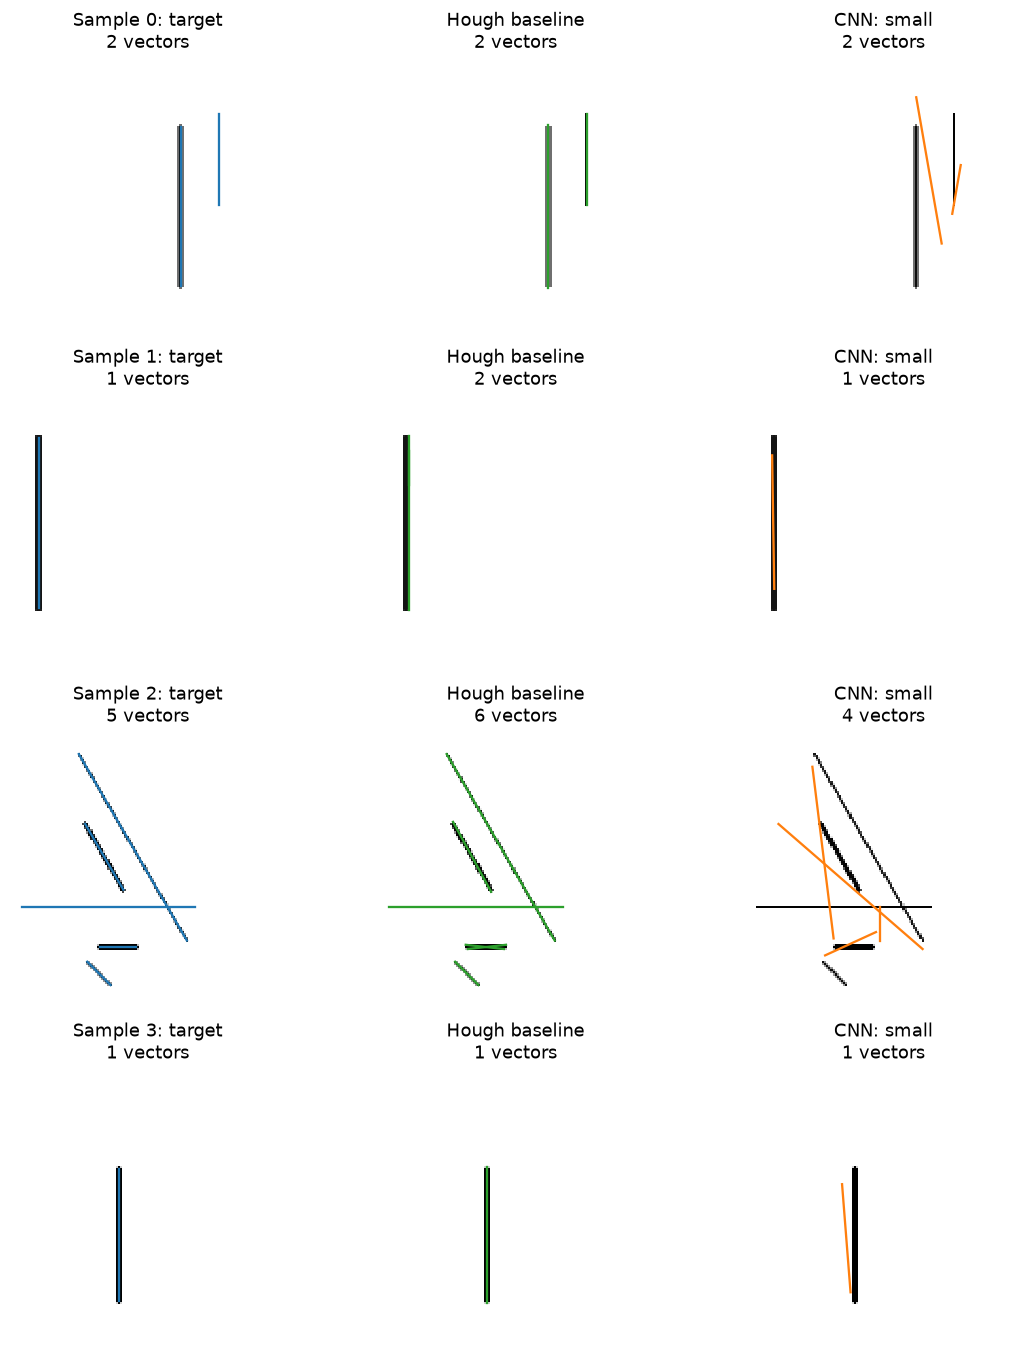

Saved visual check: cnn_distance_density_four_cycle_hough_results\visual_checks\small_visual_check.png


## Cycle: Medium (10,000 training drawings)

medium | 10,000 samples | epoch 01/15: loss=0.3063, conf=0.1157, coord=0.0191
medium | 10,000 samples | epoch 02/15: loss=0.2158, conf=0.0777, coord=0.0138
medium | 10,000 samples | epoch 03/15: loss=0.1830, conf=0.0637, coord=0.0119
medium | 10,000 samples | epoch 04/15: loss=0.1566, conf=0.0518, coord=0.0105
medium | 10,000 samples | epoch 05/15: loss=0.1377, conf=0.0455, coord=0.0092
medium | 10,000 samples | epoch 06/15: loss=0.1254, conf=0.0417, coord=0.0084
medium | 10,000 samples | epoch 07/15: loss=0.1089, conf=0.0344, coord=0.0075
medium | 10,000 samples | epoch 08/15: loss=0.0993, conf=0.0323, coord=0.0067
medium | 10,000 samples | epoch 09/15: loss=0.0856, conf=0.0273, coord=0.0058
medium | 10,000 samples | epoch 10/15: loss=0.0759, conf=0.0235, coord=0.0052
medium | 10,000 samples | epoch 11/15: loss=0.0683, conf=0.0200, coord=0.0048
medium | 10,000 samples | epoch 12/15: loss=0.0584, conf=0.0165, coord=0.0042
medium | 10,000 samples | epoch 13/15: loss=0.0592, conf=0.0178,

### Pixel-level performance

,Method,Precision,Recall,F1-score,Accuracy,IoU
0,Hough transform baseline,0.9027,0.4563,0.6062,0.9879,0.4349
1,CNN distance-density,0.0986,0.0377,0.0545,0.9733,0.0280


...

#### Hough transform baseline

,Predicted background,Predicted stroke
Actual background,19239441,19745
Actual stroke,218361,183253


### Engineering performance

,Method,True vectors,Predicted vectors,Vector count error,Engineering score,Line geometry score,Total length score,Junction angle score,Vector count score,True junctions,Predicted junctions
0,Hough transform baseline,2.9975,3.6425,0.6750,0.7858,0.8282,0.8610,0.6143,0.8735,0.4292,1.4442
1,CNN distance-density,2.9975,3.3200,0.3525,0.4847,0.1799,0.8261,0.5891,0.9126,0.4292,0.3642


### Visual comparison

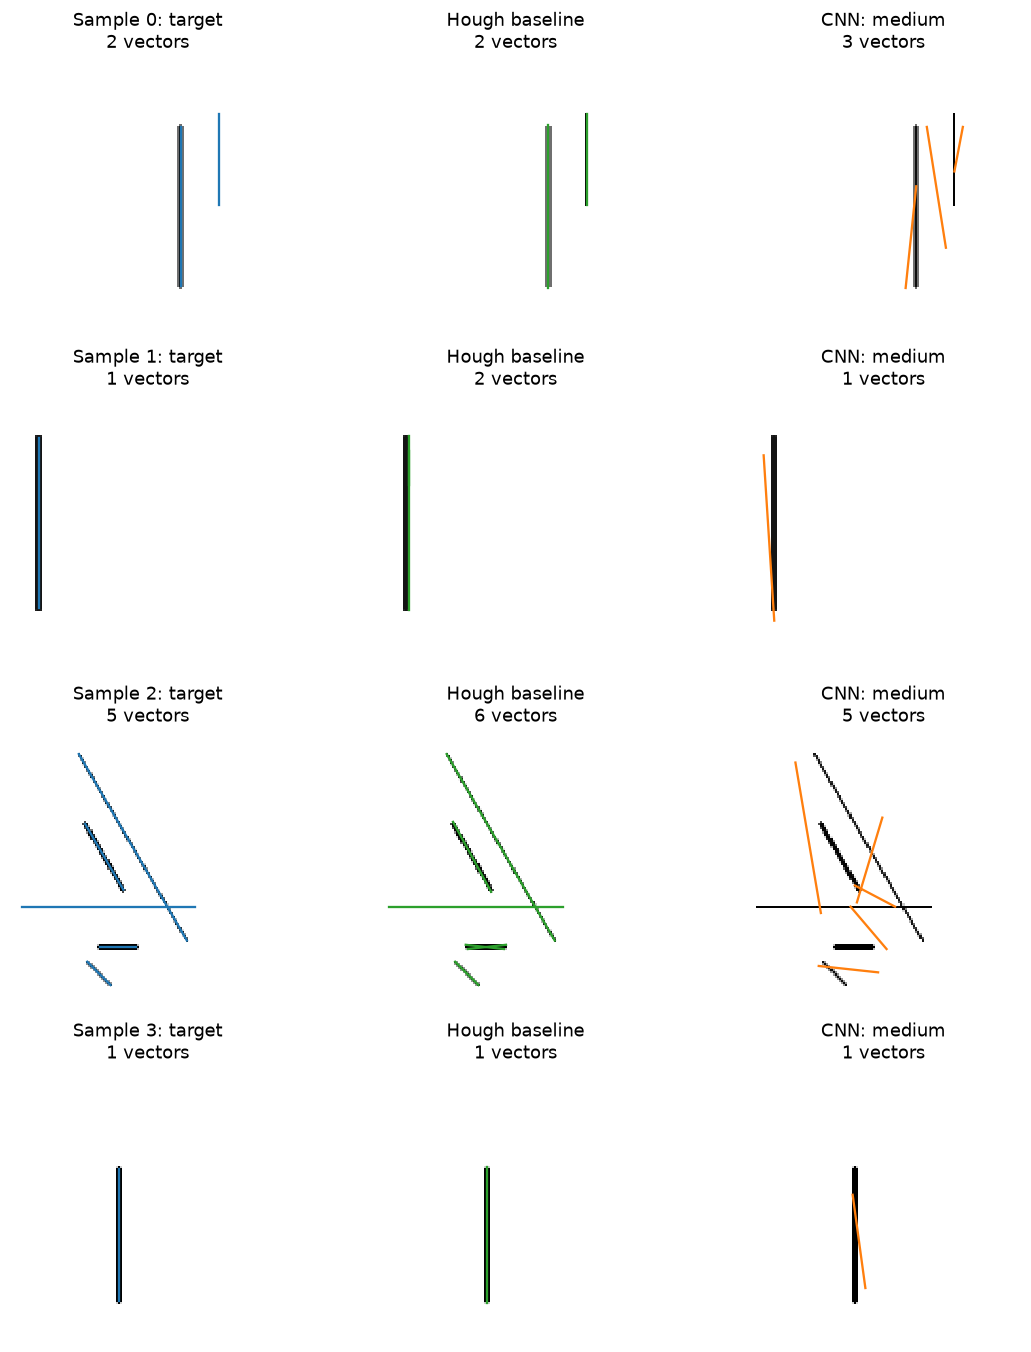

Saved visual check: cnn_distance_density_four_cycle_hough_results\visual_checks\medium_visual_check.png


## Cycle: Larger (30,000 training drawings)

larger | 30,000 samples | epoch 01/15: loss=0.2407, conf=0.0860, coord=0.0155
larger | 30,000 samples | epoch 02/15: loss=0.1693, conf=0.0543, coord=0.0115
larger | 30,000 samples | epoch 03/15: loss=0.1471, conf=0.0461, coord=0.0101
larger | 30,000 samples | epoch 04/15: loss=0.1317, conf=0.0402, coord=0.0091
larger | 30,000 samples | epoch 05/15: loss=0.1199, conf=0.0357, coord=0.0084
larger | 30,000 samples | epoch 06/15: loss=0.1114, conf=0.0334, coord=0.0078
larger | 30,000 samples | epoch 07/15: loss=0.1000, conf=0.0284, coord=0.0072
larger | 30,000 samples | epoch 08/15: loss=0.0915, conf=0.0257, coord=0.0066
larger | 30,000 samples | epoch 09/15: loss=0.0821, conf=0.0218, coord=0.0060
larger | 30,000 samples | epoch 10/15: loss=0.0746, conf=0.0189, coord=0.0056
larger | 30,000 samples | epoch 11/15: loss=0.0675, conf=0.0162, coord=0.0051
larger | 30,000 samples | epoch 12/15: loss=0.0604, conf=0.0133, coord=0.0047
larger | 30,000 samples | epoch 13/15: loss=0.0577, conf=0.0128,

### Pixel-level performance

,Method,Precision,Recall,F1-score,Accuracy,IoU
0,Hough transform baseline,0.9027,0.4563,0.6062,0.9879,0.4349
1,CNN distance-density,0.1129,0.0424,0.0617,0.9736,0.0318


...

#### Hough transform baseline

,Predicted background,Predicted stroke
Actual background,19239441,19745
Actual stroke,218361,183253


### Engineering performance

,Method,True vectors,Predicted vectors,Vector count error,Engineering score,Line geometry score,Total length score,Junction angle score,Vector count score,True junctions,Predicted junctions
0,Hough transform baseline,2.9975,3.6425,0.6750,0.7858,0.8282,0.8610,0.6143,0.8735,0.4292,1.4442
1,CNN distance-density,2.9975,3.0017,0.1242,0.5173,0.2086,0.8364,0.6367,0.9700,0.4292,0.2925


### Visual comparison

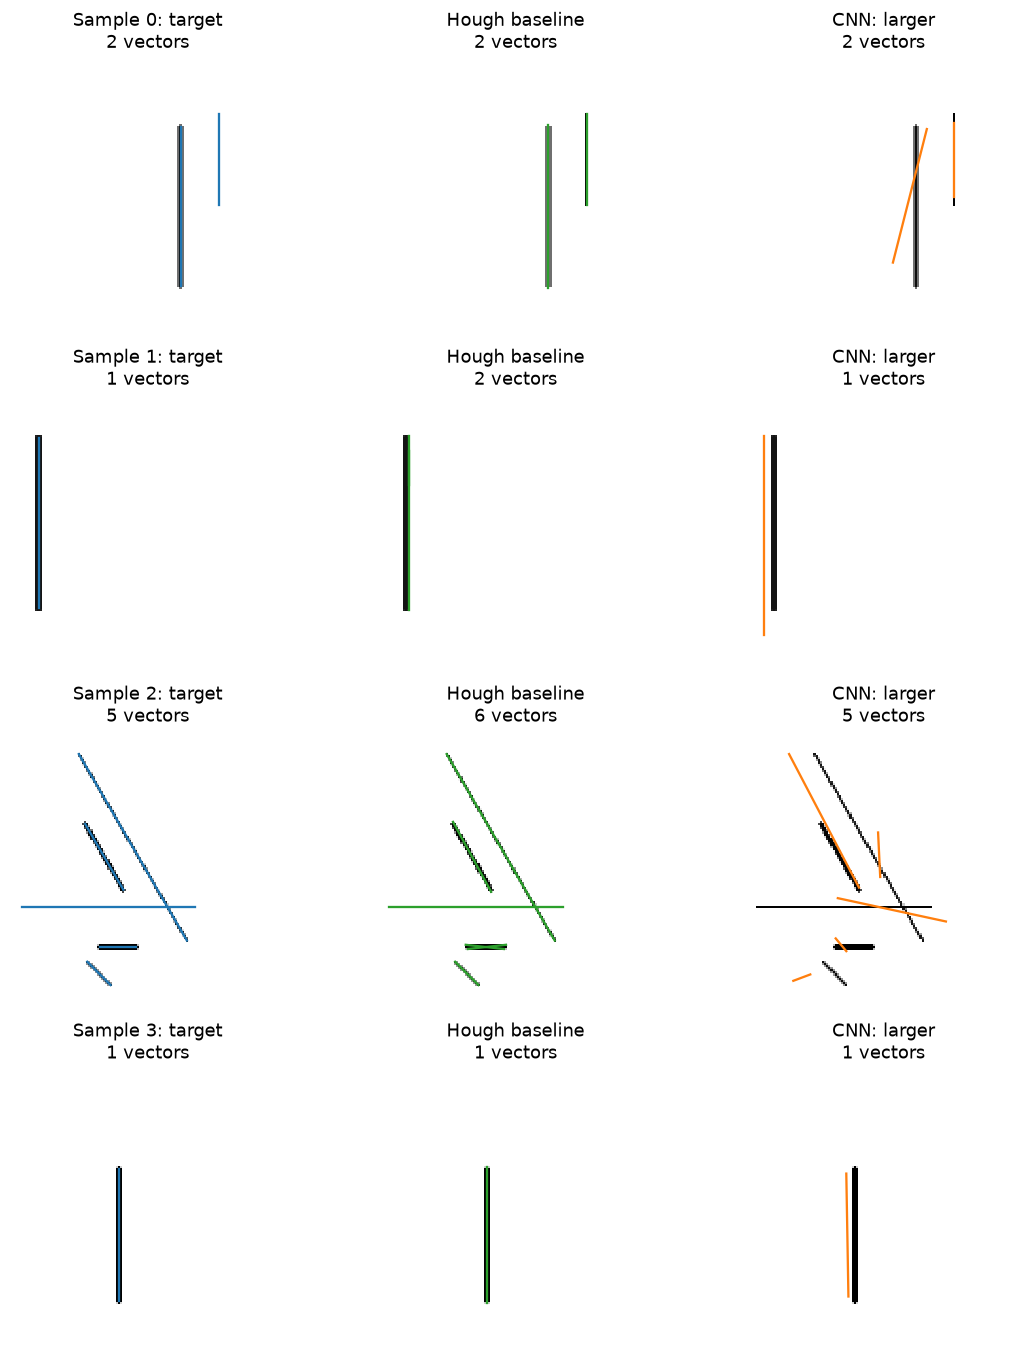

Saved visual check: cnn_distance_density_four_cycle_hough_results\visual_checks\larger_visual_check.png


## Cycle: Very Large (60,000 training drawings)

very_large | 60,000 samples | epoch 01/15: loss=0.2111, conf=0.0711, coord=0.0140
very_large | 60,000 samples | epoch 02/15: loss=0.1484, conf=0.0445, coord=0.0104
very_large | 60,000 samples | epoch 03/15: loss=0.1302, conf=0.0380, coord=0.0092
very_large | 60,000 samples | epoch 04/15: loss=0.1185, conf=0.0337, coord=0.0085
very_large | 60,000 samples | epoch 05/15: loss=0.1096, conf=0.0301, coord=0.0079
very_large | 60,000 samples | epoch 06/15: loss=0.1020, conf=0.0273, coord=0.0075
very_large | 60,000 samples | epoch 07/15: loss=0.0941, conf=0.0242, coord=0.0070
very_large | 60,000 samples | epoch 08/15: loss=0.0860, conf=0.0204, coord=0.0066
very_large | 60,000 samples | epoch 09/15: loss=0.0794, conf=0.0180, coord=0.0061
very_large | 60,000 samples | epoch 10/15: loss=0.0734, conf=0.0158, coord=0.0058
very_large | 60,000 samples | epoch 11/15: loss=0.0675, conf=0.0132, coord=0.0054
very_large | 60,000 samples | epoch 12/15: loss=0.0616, conf=0.0108, coord=0.0051
very_large | 60,

### Pixel-level performance

,Method,Precision,Recall,F1-score,Accuracy,IoU
0,Hough transform baseline,0.9027,0.4563,0.6062,0.9879,0.4349
1,CNN distance-density,0.1371,0.0532,0.0767,0.9738,0.0399


...

#### Hough transform baseline

,Predicted background,Predicted stroke
Actual background,19239441,19745
Actual stroke,218361,183253


### Engineering performance

,Method,True vectors,Predicted vectors,Vector count error,Engineering score,Line geometry score,Total length score,Junction angle score,Vector count score,True junctions,Predicted junctions
0,Hough transform baseline,2.9975,3.6425,0.6750,0.7858,0.8282,0.8610,0.6143,0.8735,0.4292,1.4442
1,CNN distance-density,2.9975,3.0333,0.1092,0.5228,0.2207,0.8556,0.6200,0.9740,0.4292,0.3975


### Visual comparison

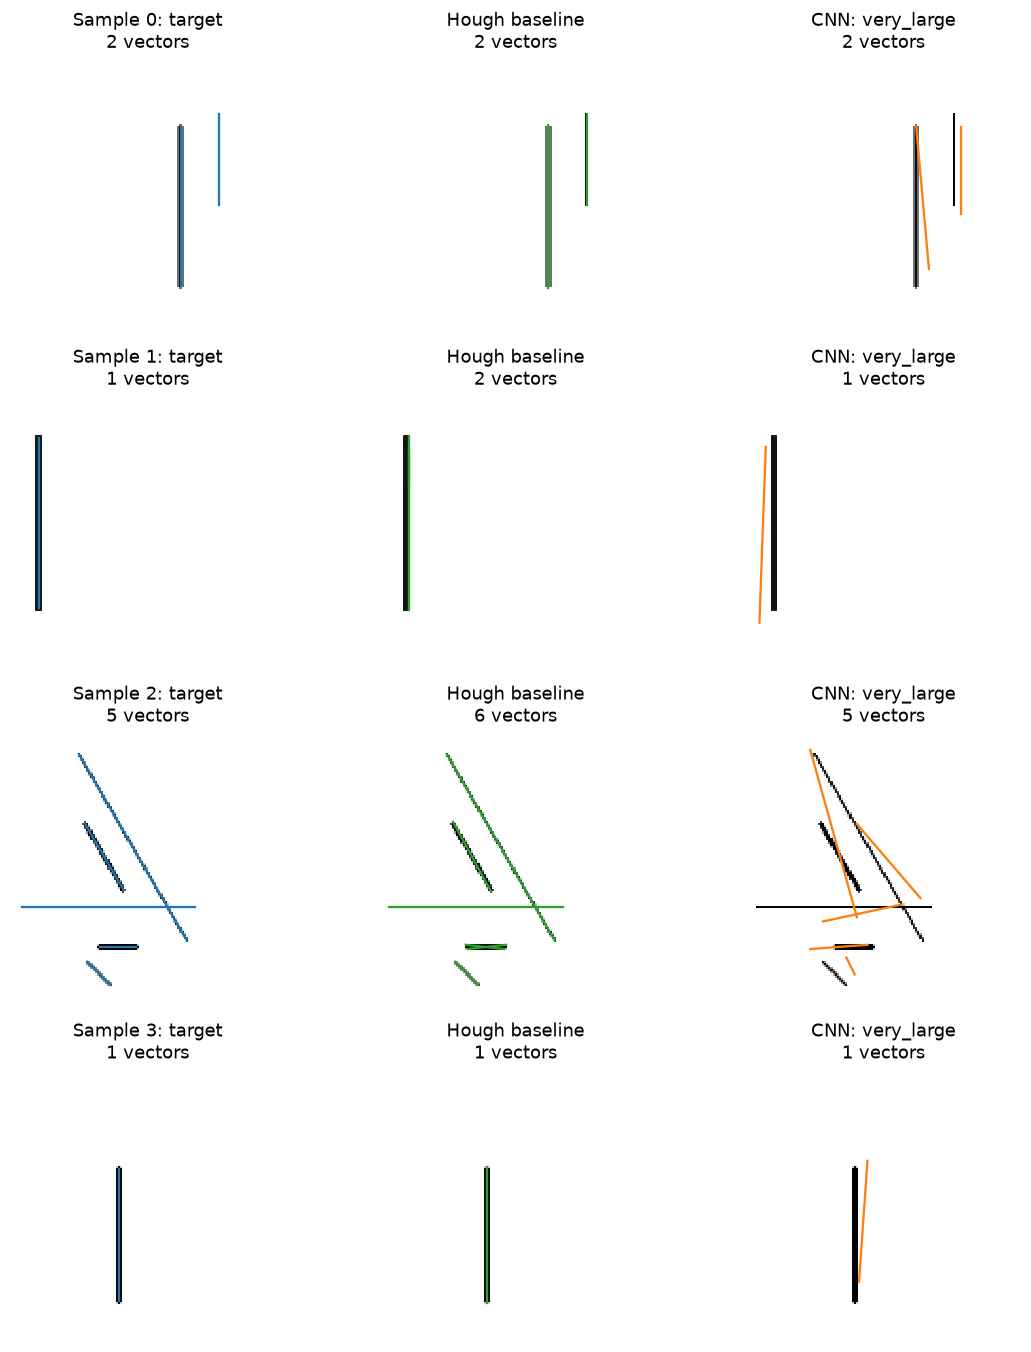

Saved visual check: cnn_distance_density_four_cycle_hough_results\visual_checks\very_large_visual_check.png
All four cycles complete.


In [8]:
CNN_METHOD_NAME = 'CNN distance-density'
HOUGH_METHOD_NAME = 'Hough transform baseline'
VISUAL_SAMPLE_INDICES = [0, 1, 2, 3]


def evaluate_vector_predictions(method_name, predictions, cycle_name, n_training_samples):
    rows = []

    for sample_idx, pred_vectors in enumerate(predictions):
        raw_image = decode_uint8(test_raw_mm[sample_idx])
        true_vectors = vector_list_from_fixed(
            test_vectors_mm[sample_idx],
            test_counts_mm[sample_idx],
        )
        pred_raster = rasterise_vectors(pred_vectors, IMG_SIZE)
        pixel = raster_metrics(raw_image, pred_raster)
        engineering = engineering_metrics(true_vectors, pred_vectors, GEOMETRY_CONFIG)

        rows.append({
            'Cycle': cycle_name,
            'Training samples': int(n_training_samples),
            'sample': sample_idx,
            'Method': method_name,
            'True vectors': len(true_vectors),
            'Predicted vectors': len(pred_vectors),
            'Vector count error': abs(len(true_vectors) - len(pred_vectors)),
            'Engineering score': engineering['engineering_score'],
            'Line geometry score': engineering['line_geometry_score'],
            'Total length score': engineering['total_length_score'],
            'Junction angle score': engineering['junction_angle_score'],
            'Vector count score': engineering['vector_count_score'],
            'True junctions': engineering['true_junctions'],
            'Predicted junctions': engineering['pred_junctions'],
            'tp': pixel['tp'],
            'fp': pixel['fp'],
            'fn': pixel['fn'],
            'tn': pixel['tn'],
            'sample_precision': pixel['precision'],
            'sample_recall': pixel['recall'],
            'sample_f1': pixel['f1'],
            'sample_accuracy': pixel['accuracy'],
            'sample_iou': pixel['iou'],
        })

    return pd.DataFrame(rows)


def build_pixel_table(cycle_df):
    counts = cycle_df.groupby('Method', as_index=False).agg(
        tp=('tp', 'sum'),
        fp=('fp', 'sum'),
        fn=('fn', 'sum'),
        tn=('tn', 'sum'),
    )
    counts['Precision'] = counts['tp'] / (counts['tp'] + counts['fp'] + 1e-9)
    counts['Recall'] = counts['tp'] / (counts['tp'] + counts['fn'] + 1e-9)
    counts['F1-score'] = (
        2 * counts['Precision'] * counts['Recall']
        / (counts['Precision'] + counts['Recall'] + 1e-9)
    )
    counts['Accuracy'] = (
        counts['tp'] + counts['tn']
    ) / (
        counts['tp'] + counts['fp'] + counts['fn'] + counts['tn'] + 1e-9
    )
    counts['IoU'] = counts['tp'] / (
        counts['tp'] + counts['fp'] + counts['fn'] + 1e-9
    )

    table = counts[[
        'Method',
        'Precision',
        'Recall',
        'F1-score',
        'Accuracy',
        'IoU',
    ]].sort_values('F1-score', ascending=False).reset_index(drop=True)
    return table.round(4), counts


def build_engineering_table(cycle_df):
    table = cycle_df.groupby('Method', as_index=False).agg(
        **{
            'True vectors': ('True vectors', 'mean'),
            'Predicted vectors': ('Predicted vectors', 'mean'),
            'Vector count error': ('Vector count error', 'mean'),
            'Engineering score': ('Engineering score', 'mean'),
            'Line geometry score': ('Line geometry score', 'mean'),
            'Total length score': ('Total length score', 'mean'),
            'Junction angle score': ('Junction angle score', 'mean'),
            'Vector count score': ('Vector count score', 'mean'),
            'True junctions': ('True junctions', 'mean'),
            'Predicted junctions': ('Predicted junctions', 'mean'),
        }
    )
    return table[[
        'Method',
        'True vectors',
        'Predicted vectors',
        'Vector count error',
        'Engineering score',
        'Line geometry score',
        'Total length score',
        'Junction angle score',
        'Vector count score',
        'True junctions',
        'Predicted junctions',
    ]].sort_values('Engineering score', ascending=False).reset_index(drop=True).round(4)


def display_confusion_matrices(counts_df):
    for _, row in counts_df.sort_values('Method').iterrows():
        matrix_df = pd.DataFrame(
            [
                [int(row['tn']), int(row['fp'])],
                [int(row['fn']), int(row['tp'])],
            ],
            index=['Actual background', 'Actual stroke'],
            columns=['Predicted background', 'Predicted stroke'],
        )
        display(Markdown(f'#### {row["Method"]}'))
        display(matrix_df)


def draw_vectors(axis, image, vectors, title, colour):
    axis.imshow(image, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    for x0, y0, x1, y1 in vectors:
        axis.plot([x0, x1], [y0, y1], color=colour, linewidth=1.5)
    axis.set_title(title)
    axis.set_xlim(-1, IMG_SIZE)
    axis.set_ylim(IMG_SIZE, -1)
    axis.set_aspect('equal')
    axis.axis('off')


def display_and_save_cycle_visuals(cycle_name, cnn_predictions, hough_predictions):
    valid_indices = [idx for idx in VISUAL_SAMPLE_INDICES if idx < N_TEST]
    fig, axes = plt.subplots(
        len(valid_indices),
        3,
        figsize=(10.5, 3.1 * len(valid_indices)),
        dpi=110,
        squeeze=False,
    )

    for row_idx, sample_idx in enumerate(valid_indices):
        raw_image = decode_uint8(test_raw_mm[sample_idx])
        true_vectors = vector_list_from_fixed(
            test_vectors_mm[sample_idx],
            test_counts_mm[sample_idx],
        )
        draw_vectors(
            axes[row_idx, 0],
            raw_image,
            true_vectors,
            f'Sample {sample_idx}: target\n{len(true_vectors)} vectors',
            'tab:blue',
        )
        draw_vectors(
            axes[row_idx, 1],
            raw_image,
            hough_predictions[sample_idx],
            f'Hough baseline\n{len(hough_predictions[sample_idx])} vectors',
            'tab:green',
        )
        draw_vectors(
            axes[row_idx, 2],
            raw_image,
            cnn_predictions[sample_idx],
            f'CNN: {cycle_name}\n{len(cnn_predictions[sample_idx])} vectors',
            'tab:orange',
        )

    fig.tight_layout()
    output_path = VISUAL_DIR / f'{cycle_name}_visual_check.png'
    fig.savefig(output_path, bbox_inches='tight', dpi=140)
    plt.show()
    return output_path


# -----------------------------------------------------------------------------
# Fixed Hough baseline: calculate once and reuse in every cycle.
# -----------------------------------------------------------------------------
print(f'Evaluating fixed Hough baseline on {N_TEST:,} test drawings...')
hough_predictions = []
hough_debug_summary = []
hough_started = time.perf_counter()

for sample_idx in range(N_TEST):
    raw_image = decode_uint8(test_raw_mm[sample_idx])
    vectors, debug = reconstruct_vectors_hough_transform(raw_image)
    hough_predictions.append(vectors)
    hough_debug_summary.append({
        'sample': sample_idx,
        'candidate_peak_count': debug.get('candidate_peak_count', 0),
        'selected_peak_count': len(debug.get('selected_peaks', [])),
        'predicted_vectors': len(vectors),
    })

    if (sample_idx + 1) % 200 == 0 or sample_idx + 1 == N_TEST:
        print(f'  Hough: {sample_idx + 1:,}/{N_TEST:,} test drawings')

pd.DataFrame(hough_debug_summary).to_csv(
    OUTPUT_DIR / 'hough_debug_summary.csv',
    index=False,
)
print(f'Hough evaluation finished in {(time.perf_counter() - hough_started) / 60:.1f} minutes.')


# -----------------------------------------------------------------------------
# Four independent CNN training/evaluation cycles.
# -----------------------------------------------------------------------------
all_history_frames = []
all_result_frames = []
all_pixel_tables = []
all_engineering_tables = []
cycle_visual_files = []

for cycle_name, n_training_samples in TRAINING_CYCLES.items():
    display(Markdown(
        f'## Cycle: {cycle_name.replace("_", " ").title()} '
        f'({n_training_samples:,} training drawings)'
    ))

    model, history_df = train_cycle_model(cycle_name, n_training_samples)
    all_history_frames.append(history_df)

    model_path = MODEL_DIR / f'distance_density_{cycle_name}_{n_training_samples}.pt'
    torch.save({
        'state_dict': model.state_dict(),
        'cycle': cycle_name,
        'training_samples': int(n_training_samples),
        'model_config': DIRECT_VECTOR_MODEL_CONFIG,
        'preprocess_config': DISTANCE_DENSITY_CONFIG,
        'img_size': IMG_SIZE,
        'max_vectors': MAX_VECTORS,
    }, model_path)
    print('Saved model:', model_path)

    cnn_predictions = []
    for sample_idx in range(N_TEST):
        vectors, _ = predict_cnn_vectors(model, test_inputs_mm[sample_idx])
        cnn_predictions.append(vectors)

        if (sample_idx + 1) % 200 == 0 or sample_idx + 1 == N_TEST:
            print(f'  CNN evaluation: {sample_idx + 1:,}/{N_TEST:,} test drawings')

    cnn_df = evaluate_vector_predictions(
        CNN_METHOD_NAME,
        cnn_predictions,
        cycle_name,
        n_training_samples,
    )
    hough_df = evaluate_vector_predictions(
        HOUGH_METHOD_NAME,
        hough_predictions,
        cycle_name,
        n_training_samples,
    )
    cycle_df = pd.concat([cnn_df, hough_df], ignore_index=True)
    all_result_frames.append(cycle_df)

    pixel_table_df, confusion_counts_df = build_pixel_table(cycle_df)
    engineering_table_df = build_engineering_table(cycle_df)

    pixel_export = pixel_table_df.copy()
    pixel_export.insert(0, 'Training samples', int(n_training_samples))
    pixel_export.insert(0, 'Cycle', cycle_name)
    engineering_export = engineering_table_df.copy()
    engineering_export.insert(0, 'Training samples', int(n_training_samples))
    engineering_export.insert(0, 'Cycle', cycle_name)
    all_pixel_tables.append(pixel_export)
    all_engineering_tables.append(engineering_export)

    cycle_df.to_csv(CYCLE_DIR / f'{cycle_name}_per_sample_results.csv', index=False)
    pixel_table_df.to_csv(CYCLE_DIR / f'{cycle_name}_pixel_performance.csv', index=False)
    engineering_table_df.to_csv(CYCLE_DIR / f'{cycle_name}_engineering_performance.csv', index=False)
    confusion_counts_df.to_csv(CYCLE_DIR / f'{cycle_name}_confusion_counts.csv', index=False)
    history_df.to_csv(CYCLE_DIR / f'{cycle_name}_training_history.csv', index=False)

    display(Markdown('### Pixel-level performance'))
    display(pixel_table_df[[
        'Method', 'Precision', 'Recall', 'F1-score', 'Accuracy', 'IoU'
    ]])

    display(Markdown('### Confusion matrices'))
    display_confusion_matrices(confusion_counts_df)

    display(Markdown('### Engineering performance'))
    display(engineering_table_df[[
        'Method',
        'True vectors',
        'Predicted vectors',
        'Vector count error',
        'Engineering score',
        'Line geometry score',
        'Total length score',
        'Junction angle score',
        'Vector count score',
        'True junctions',
        'Predicted junctions',
    ]])

    display(Markdown('### Visual comparison'))
    visual_path = display_and_save_cycle_visuals(
        cycle_name,
        cnn_predictions,
        hough_predictions,
    )
    cycle_visual_files.append(visual_path)
    print('Saved visual check:', visual_path)

    # Predictions have been scored and selected examples retained; release the full list.
    del cnn_predictions, model
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


all_training_history_df = pd.concat(all_history_frames, ignore_index=True)
all_results_df = pd.concat(all_result_frames, ignore_index=True)
all_pixel_performance_df = pd.concat(all_pixel_tables, ignore_index=True)
all_engineering_performance_df = pd.concat(all_engineering_tables, ignore_index=True)

all_training_history_df.to_csv(OUTPUT_DIR / 'all_training_history.csv', index=False)
all_results_df.to_csv(OUTPUT_DIR / 'all_cycle_per_sample_results.csv', index=False)
all_pixel_performance_df.to_csv(OUTPUT_DIR / 'all_cycle_pixel_performance.csv', index=False)
all_engineering_performance_df.to_csv(
    OUTPUT_DIR / 'all_cycle_engineering_performance.csv',
    index=False,
)

print('All four cycles complete.')

## Cross-cycle summary

These tables place all four CNN runs beside the repeated fixed Hough baseline. The plots show how training loss and headline evaluation scores change as the training set grows.

## Combined pixel-level performance

,Cycle,Training samples,Method,Precision,Recall,F1-score,Accuracy,IoU
0,small,2000,Hough transform baseline,0.9027,0.4563,0.6062,0.9879,0.4349
1,small,2000,CNN distance-density,0.0813,0.0288,0.0425,0.9735,0.0217
2,medium,10000,Hough transform baseline,0.9027,0.4563,0.6062,0.9879,0.4349
3,medium,10000,CNN distance-density,0.0986,0.0377,0.0545,0.9733,0.0280
4,larger,30000,Hough transform baseline,0.9027,0.4563,0.6062,0.9879,0.4349
5,larger,30000,CNN distance-density,0.1129,0.0424,0.0617,0.9736,0.0318
6,very_large,60000,Hough transform baseline,0.9027,0.4563,0.6062,0.9879,0.4349
7,very_large,60000,CNN distance-density,0.1371,0.0532,0.0767,0.9738,0.0399


## Combined engineering performance

,Cycle,Training samples,Method,True vectors,Predicted vectors,Vector count error,Engineering score,Line geometry score,Total length score,Junction angle score,Vector count score,True junctions,Predicted junctions
0,small,2000,Hough transform baseline,2.9975,3.6425,0.6750,0.7858,0.8282,0.8610,0.6143,0.8735,0.4292,1.4442
1,small,2000,CNN distance-density,2.9975,3.0075,0.3883,0.4591,0.1436,0.7842,0.5920,0.8962,0.4292,0.4200
2,medium,10000,Hough transform baseline,2.9975,3.6425,0.6750,0.7858,0.8282,0.8610,0.6143,0.8735,0.4292,1.4442
3,medium,10000,CNN distance-density,2.9975,3.3200,0.3525,0.4847,0.1799,0.8261,0.5891,0.9126,0.4292,0.3642
4,larger,30000,Hough transform baseline,2.9975,3.6425,0.6750,0.7858,0.8282,0.8610,0.6143,0.8735,0.4292,1.4442
5,larger,30000,CNN distance-density,2.9975,3.0017,0.1242,0.5173,0.2086,0.8364,0.6367,0.9700,0.4292,0.2925
6,very_large,60000,Hough transform baseline,2.9975,3.6425,0.6750,0.7858,0.8282,0.8610,0.6143,0.8735,0.4292,1.4442
7,very_large,60000,CNN distance-density,2.9975,3.0333,0.1092,0.5228,0.2207,0.8556,0.6200,0.9740,0.4292,0.3975


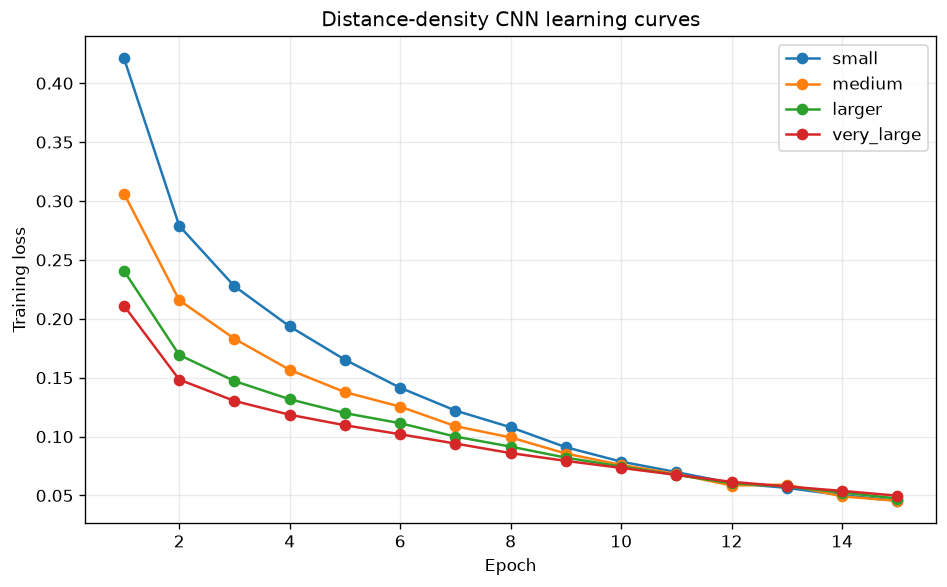

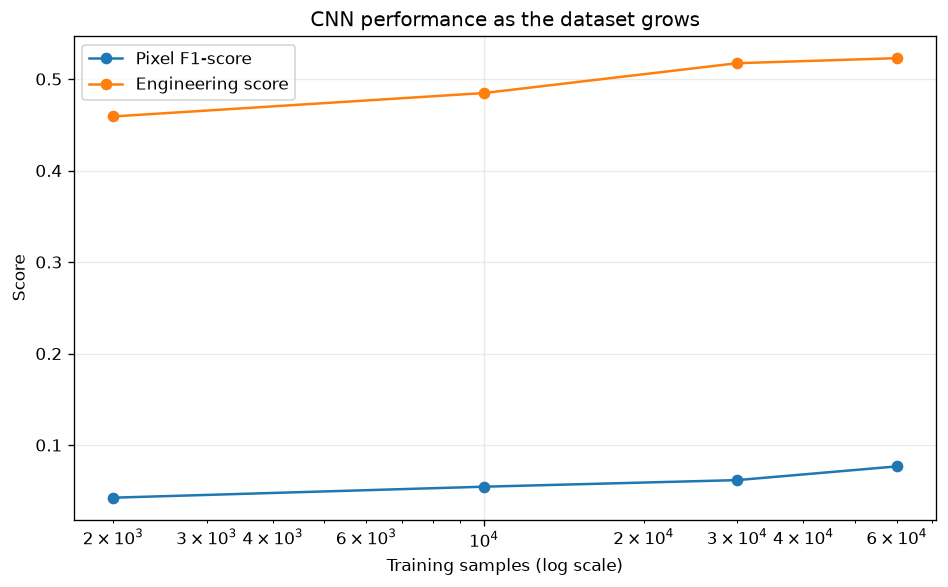

## Saved outputs

,Output,Path
0,Exported maximum synthetic dataset,cnn_distance_density_four_cycle_hough_results\...
1,All training histories,cnn_distance_density_four_cycle_hough_results\...
2,All per-sample results,cnn_distance_density_four_cycle_hough_results\...
3,Combined pixel table,cnn_distance_density_four_cycle_hough_results\...
4,Combined engineering table,cnn_distance_density_four_cycle_hough_results\...
5,Learning-curve plot,cnn_distance_density_four_cycle_hough_results\...
6,Dataset-scaling plot,cnn_distance_density_four_cycle_hough_results\...
7,Models,cnn_distance_density_four_cycle_hough_results\...
8,Per-cycle outputs,cnn_distance_density_four_cycle_hough_results\...
9,Compact visual checks,cnn_distance_density_four_cycle_hough_results\...


Main output folder: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_density_four_cycle_hough_results


In [9]:
display(Markdown('## Combined pixel-level performance'))
display(all_pixel_performance_df[[
    'Cycle',
    'Training samples',
    'Method',
    'Precision',
    'Recall',
    'F1-score',
    'Accuracy',
    'IoU',
]])

display(Markdown('## Combined engineering performance'))
display(all_engineering_performance_df[[
    'Cycle',
    'Training samples',
    'Method',
    'True vectors',
    'Predicted vectors',
    'Vector count error',
    'Engineering score',
    'Line geometry score',
    'Total length score',
    'Junction angle score',
    'Vector count score',
    'True junctions',
    'Predicted junctions',
]])

# Training-loss curves.
fig, axis = plt.subplots(figsize=(8, 5), dpi=120)
for cycle_name, group in all_training_history_df.groupby('Cycle', sort=False):
    axis.plot(group['Epoch'], group['Loss'], marker='o', label=cycle_name)
axis.set_xlabel('Epoch')
axis.set_ylabel('Training loss')
axis.set_title('Distance-density CNN learning curves')
axis.grid(True, alpha=0.25)
axis.legend()
fig.tight_layout()
learning_curve_path = OUTPUT_DIR / 'training_loss_by_cycle.png'
fig.savefig(learning_curve_path, bbox_inches='tight', dpi=160)
plt.show()

# CNN scaling summary; Hough is omitted here because it does not use training data.
cnn_pixel_scaling = all_pixel_performance_df[
    all_pixel_performance_df['Method'] == CNN_METHOD_NAME
].sort_values('Training samples')
cnn_engineering_scaling = all_engineering_performance_df[
    all_engineering_performance_df['Method'] == CNN_METHOD_NAME
].sort_values('Training samples')

fig, axis = plt.subplots(figsize=(8, 5), dpi=120)
axis.plot(
    cnn_pixel_scaling['Training samples'],
    cnn_pixel_scaling['F1-score'],
    marker='o',
    label='Pixel F1-score',
)
axis.plot(
    cnn_engineering_scaling['Training samples'],
    cnn_engineering_scaling['Engineering score'],
    marker='o',
    label='Engineering score',
)
axis.set_xscale('log')
axis.set_xlabel('Training samples (log scale)')
axis.set_ylabel('Score')
axis.set_title('CNN performance as the dataset grows')
axis.grid(True, alpha=0.25)
axis.legend()
fig.tight_layout()
scaling_plot_path = OUTPUT_DIR / 'cnn_score_vs_training_size.png'
fig.savefig(scaling_plot_path, bbox_inches='tight', dpi=160)
plt.show()

run_config = {
    'output_folder': OUTPUT_FOLDER_NAME,
    'dataset_seed': DATASET_SEED,
    'model_seed': MODEL_SEED,
    'training_cycles': dict(TRAINING_CYCLES),
    'test_images': N_TEST,
    'batch_size': BATCH_SIZE,
    'epochs_per_cycle': CNN_EPOCHS,
    'learning_rate': LEARNING_RATE,
    'distance_density_config': DISTANCE_DENSITY_CONFIG,
    'hough_config': CLASSIC_VECTOR_CONFIG['hough'],
}
(OUTPUT_DIR / 'run_config.json').write_text(
    json.dumps(run_config, indent=2),
    encoding='utf-8',
)

saved_files_df = pd.DataFrame({
    'Output': [
        'Exported maximum synthetic dataset',
        'All training histories',
        'All per-sample results',
        'Combined pixel table',
        'Combined engineering table',
        'Learning-curve plot',
        'Dataset-scaling plot',
        'Models',
        'Per-cycle outputs',
        'Compact visual checks',
        'Run configuration',
    ],
    'Path': [
        DATASET_DIR,
        OUTPUT_DIR / 'all_training_history.csv',
        OUTPUT_DIR / 'all_cycle_per_sample_results.csv',
        OUTPUT_DIR / 'all_cycle_pixel_performance.csv',
        OUTPUT_DIR / 'all_cycle_engineering_performance.csv',
        learning_curve_path,
        scaling_plot_path,
        MODEL_DIR,
        CYCLE_DIR,
        VISUAL_DIR,
        OUTPUT_DIR / 'run_config.json',
    ],
})

display(Markdown('## Saved outputs'))
display(saved_files_df)
print('Main output folder:', OUTPUT_DIR.resolve())

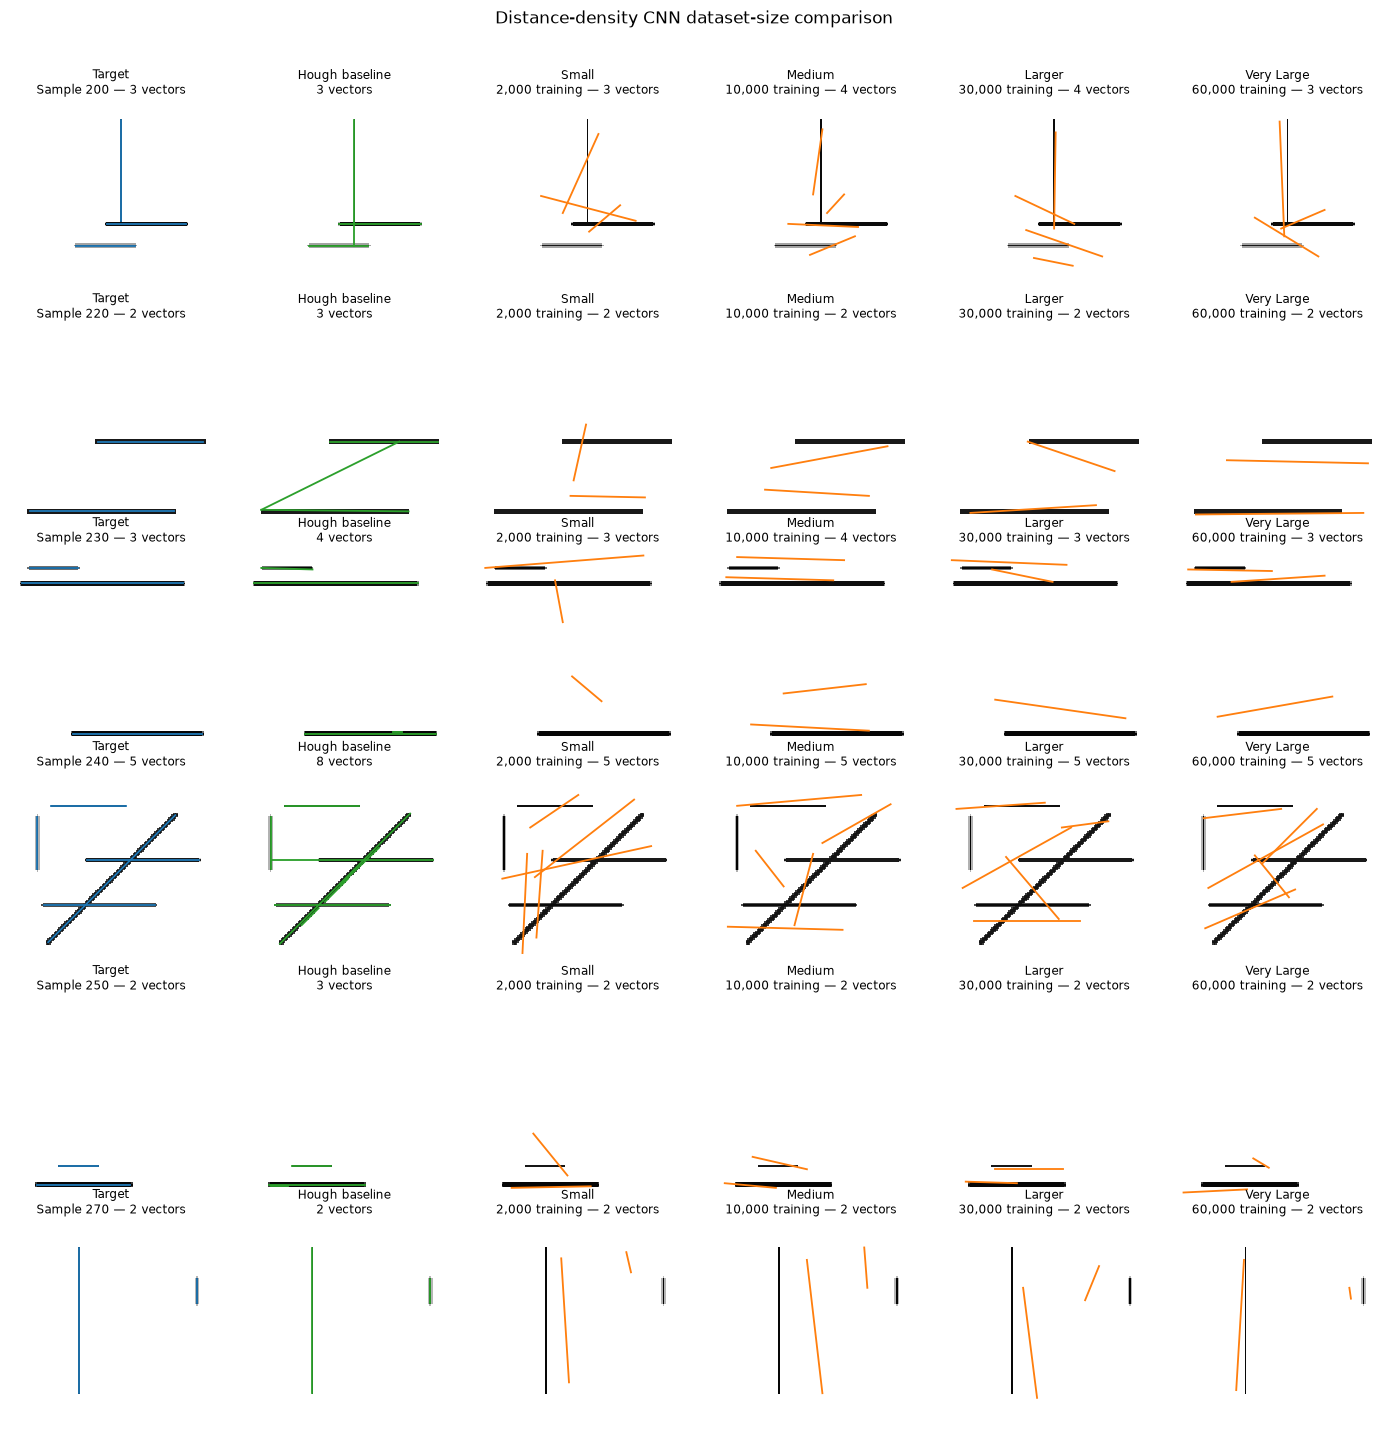

Compact side-by-side PNG saved to:
C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_density_four_cycle_hough_results\visual_checks\all_cycles_side_by_side_compact.png


In [13]:
# ============================================================================
# Compact side-by-side comparison:
# Target | Hough | Small | Medium | Larger | Very large
# ============================================================================

# Change these to select different test examples.
# Keeping this to three samples produces a manageable PNG.
SIDE_BY_SIDE_SAMPLE_INDICES = [200, 220, 230, 240, 250, 270]

SIDE_BY_SIDE_OUTPUT_PATH = (
    VISUAL_DIR / "all_cycles_side_by_side_compact.png"
)

valid_sample_indices = [
    sample_idx
    for sample_idx in SIDE_BY_SIDE_SAMPLE_INDICES
    if 0 <= sample_idx < N_TEST
]

if not valid_sample_indices:
    raise ValueError(
        "SIDE_BY_SIDE_SAMPLE_INDICES does not contain any valid test indices."
    )


def draw_compact_vectors(axis, image, vectors, title, colour):
    """Draw one compact raster/vector comparison panel."""
    axis.imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )

    for x0, y0, x1, y1 in vectors:
        axis.plot(
            [x0, x1],
            [y0, y1],
            color=colour,
            linewidth=1.2,
        )

    axis.set_title(title, fontsize=8, pad=3)
    axis.set_xlim(-1, IMG_SIZE)
    axis.set_ylim(IMG_SIZE, -1)
    axis.set_aspect("equal")
    axis.axis("off")


# ---------------------------------------------------------------------------
# Generate the Hough predictions for only the selected examples.
# ---------------------------------------------------------------------------
selected_hough_predictions = {}

for sample_idx in valid_sample_indices:
    raw_image = decode_uint8(test_raw_mm[sample_idx])

    predicted_vectors, _ = reconstruct_vectors_hough_transform(
        raw_image
    )

    selected_hough_predictions[sample_idx] = predicted_vectors


# ---------------------------------------------------------------------------
# Load each saved CNN model and predict only the selected examples.
# ---------------------------------------------------------------------------
selected_cnn_predictions = {}

for cycle_name, n_training_samples in TRAINING_CYCLES.items():

    model_path = (
        MODEL_DIR
        / f"distance_density_{cycle_name}_{n_training_samples}.pt"
    )

    if not model_path.exists():
        raise FileNotFoundError(
            f"Saved model not found: {model_path}\n"
            "Run the four training cycles before running this cell."
        )

    checkpoint = torch.load(
        model_path,
        map_location=DEVICE,
    )

    model = DirectLineCNN(
        input_channels=int(
            DIRECT_VECTOR_MODEL_CONFIG["input_channels"]
        ),
        max_vectors=MAX_VECTORS,
    ).to(DEVICE)

    model.load_state_dict(checkpoint["state_dict"])
    model.eval()

    selected_cnn_predictions[cycle_name] = {}

    for sample_idx in valid_sample_indices:
        predicted_vectors, _ = predict_cnn_vectors(
            model,
            test_inputs_mm[sample_idx],
        )

        selected_cnn_predictions[cycle_name][sample_idx] = (
            predicted_vectors
        )

    del model

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


# ---------------------------------------------------------------------------
# Draw all methods side by side.
# ---------------------------------------------------------------------------
cycle_names = list(TRAINING_CYCLES.keys())

column_count = 2 + len(cycle_names)
row_count = len(valid_sample_indices)

fig, axes = plt.subplots(
    row_count,
    column_count,
    figsize=(2.15 * column_count, 2.15 * row_count),
    dpi=110,
    squeeze=False,
)

for row_index, sample_idx in enumerate(valid_sample_indices):

    raw_image = decode_uint8(test_raw_mm[sample_idx])

    true_vectors = vector_list_from_fixed(
        test_vectors_mm[sample_idx],
        test_counts_mm[sample_idx],
    )

    # Target
    draw_compact_vectors(
        axes[row_index, 0],
        raw_image,
        true_vectors,
        (
            f"Target\n"
            f"Sample {sample_idx} — {len(true_vectors)} vectors"
        ),
        "tab:blue",
    )

    # Hough baseline
    hough_vectors = selected_hough_predictions[sample_idx]

    draw_compact_vectors(
        axes[row_index, 1],
        raw_image,
        hough_vectors,
        f"Hough baseline\n{len(hough_vectors)} vectors",
        "tab:green",
    )

    # CNN cycles: small, medium, larger and very large
    for cycle_column, cycle_name in enumerate(
        cycle_names,
        start=2,
    ):
        cnn_vectors = selected_cnn_predictions[
            cycle_name
        ][sample_idx]

        training_samples = TRAINING_CYCLES[cycle_name]

        display_cycle_name = cycle_name.replace(
            "_",
            " ",
        ).title()

        draw_compact_vectors(
            axes[row_index, cycle_column],
            raw_image,
            cnn_vectors,
            (
                f"{display_cycle_name}\n"
                f"{training_samples:,} training — "
                f"{len(cnn_vectors)} vectors"
            ),
            "tab:orange",
        )

fig.suptitle(
    "Distance-density CNN dataset-size comparison",
    fontsize=11,
    y=1.002,
)

fig.subplots_adjust(
    left=0.01,
    right=0.99,
    top=0.94,
    bottom=0.01,
    wspace=0.04,
    hspace=0.12,
)

fig.savefig(
    SIDE_BY_SIDE_OUTPUT_PATH,
    dpi=160,
    bbox_inches="tight",
    pad_inches=0.05,
    facecolor="white",
)

plt.show()
plt.close(fig)

print("Compact side-by-side PNG saved to:")
print(SIDE_BY_SIDE_OUTPUT_PATH.resolve())

## Experiment notes

- The synthetic drawing distribution, vector limits, line widths, fade range, angle-family weights and rasterisation logic are retained from the previous notebook.
- `distance_density` is the only CNN input method. It is a two-channel input, not two separately trained preprocessing models.
- All cycles use nested prefixes of the same exported 60,000-sample training dataset.
- All cycles use the same 1,200-sample test set, 15 epochs and learning rate of `3e-4`.
- Every CNN starts from the same model seed so dataset size is the principal changed factor.
- The Hough transform is non-learning and is therefore evaluated once, then shown beside every CNN cycle.
- The Hough routine uses the thresholded original raster supplied to it and does not apply internal skeletonisation.
- Large arrays are memory-mapped from the `synthetic_dataset` subfolder to avoid loading the complete dataset into RAM.
- Change the values in `TRAINING_CYCLES` to resize the four experiments. If the maximum size or data configuration is changed after a dataset has already been exported, set `REGENERATE_DATASET = True` for the next run.